# Mamba SAE full-grid 結果の分析（state / delta）

`train_sae.py` が出力する `grid_results.jsonl` を読み込み、レイヤ × signal ごとに

- seed を平均したベストハイパラ（mean best_val_recon 最小）
- ベスト run（単一 seed）
- layer 方向の傾向
- 2D heatmap / trade-off 可視化

を確認します。


In [27]:
# 0) セットアップ & 実験ディレクトリ解決
from pathlib import Path
import os, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

try:
    import yaml
except ImportError as e:
    raise ImportError("PyYAML が必要です: pip install pyyaml") from e

# まず configs/mamba_full_grid.yaml を探す（見つからない環境でも動くようにフォールバックあり）
# - repo 配下で実行しているなら自動で見つかるはず
# - もし見つからなければ、MODEL_DIR を自動探索して grid_results.jsonl から解析します
#
# 手動指定したい場合:
# CONFIG_PATH = Path("/path/to/.../configs/mamba_full_grid.yaml")
# MODEL_DIR = Path("/path/to/output_root/<model_dir_name>")

here = Path.cwd().resolve()


def try_find_config_path(start: Path) -> Path | None:
    rel = Path("configs/mamba_full_grid.yaml")
    for p in [start] + list(start.parents):
        cand = p / rel
        if cand.exists():
            return cand
    for cand in start.glob("*/configs/mamba_full_grid.yaml"):
        if cand.exists():
            return cand
    home = Path.home().resolve()
    for pat in ["*/configs/mamba_full_grid.yaml", "*/*/configs/mamba_full_grid.yaml"]:
        for cand in home.glob(pat):
            if cand.exists():
                return cand
    return None


def find_model_dirs_from_grid(start: Path) -> list[Path]:
    # grid_results.jsonl の場所から model_dir (= .../<model>/layer_X/<signal>/grid_results.jsonl の <model>) を推定
    patterns = [
        "runs/**/layer_*/state/grid_results.jsonl",
        "runs/**/layer_*/delta/grid_results.jsonl",
        "**/layer_*/state/grid_results.jsonl",
        "**/layer_*/delta/grid_results.jsonl",
    ]

    found = []
    # まずは cwd と cwd/runs だけ（速い）
    search_roots = [start, start / "runs"]
    # 次に home 配下（/workspace のような場合の救済）
    search_roots += [Path.home(), Path.home() / "runs"]
    # 典型: /raid/sasaki/runs 配下も見る（環境依存だが、ここにあることが多い）
    raid_runs = Path("/raid/sasaki/runs")
    if raid_runs.exists():
        search_roots.append(raid_runs)

    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        for pat in patterns[:2]:
            for p in root.glob(pat):
                try:
                    model_dir = p.parents[2]
                except Exception:
                    continue
                if model_dir not in seen:
                    seen.add(model_dir)
                    found.append(model_dir)
    return found


def find_model_dirs_from_output_root(output_root: Path, model_dir_name: str) -> list[Path]:
    # output_root/<run_id>/<model_dir_name>/layer_*/(state|delta)/grid_results.jsonl を想定
    patterns = [
        f"*/{model_dir_name}/layer_*/state/grid_results.jsonl",
        f"*/{model_dir_name}/layer_*/delta/grid_results.jsonl",
    ]
    found = []
    seen = set()
    for pat in patterns:
        for p in output_root.glob(pat):
            try:
                model_dir = p.parents[2]
            except Exception:
                continue
            if model_dir not in seen:
                seen.add(model_dir)
                found.append(model_dir)
    return found


def pick_best_model_dir(cands: list[Path]) -> Path:
    if not cands:
        raise FileNotFoundError(
            "configs/mamba_full_grid.yaml が見つからず、grid_results.jsonl からも MODEL_DIR を特定できませんでした。"
            "MODEL_DIR を手動指定してください（出力の <output_root>/<model_dir_name>）。"
        )
    scored = []
    for d in cands:
        n = len(list(d.glob("layer_*/state/grid_results.jsonl"))) + len(list(d.glob("layer_*/delta/grid_results.jsonl")))
        scored.append((n, d))
    scored.sort(reverse=True, key=lambda x: x[0])
    return scored[0][1]


def model_dir_has_grid_results(model_dir: Path | None) -> bool:
    if model_dir is None or not Path(model_dir).exists():
        return False
    d = Path(model_dir)
    return bool(list(d.glob("layer_*/state/grid_results.jsonl")) or list(d.glob("layer_*/delta/grid_results.jsonl")))


cfg = None
CONFIG_PATH = None
REPO_ROOT = None
output_root = None
model_name = None
model_dir = None
model_dir_name = None

if "CONFIG_PATH" in globals() and globals()["CONFIG_PATH"] is not None:
    _cand = Path(globals()["CONFIG_PATH"]).expanduser().resolve()
    CONFIG_PATH = _cand if _cand.exists() else None
if CONFIG_PATH is None:
    CONFIG_PATH = try_find_config_path(here)

if CONFIG_PATH is not None and CONFIG_PATH.exists():
    REPO_ROOT = CONFIG_PATH.parent.parent
    cfg = yaml.safe_load(CONFIG_PATH.read_text())
    output_root = Path(os.path.expanduser(os.path.expandvars(cfg["output_root"])))
    model_name = cfg["model_name"]
    model_dir_name = model_name.split("/")[-1].replace("-", "_")
    model_dir = output_root / model_dir_name
    print("CONFIG_PATH:", CONFIG_PATH)
    print("output_root:", output_root)
    print("model_dir:", model_dir)

# 1) 手動指定があれば最優先
if model_dir is None and ("MODEL_DIR" in globals()) and (globals()["MODEL_DIR"] is not None):
    model_dir = Path(globals()["MODEL_DIR"]).expanduser().resolve()

# 2) config 由来の model_dir が存在しても、grid_results が無ければ探索へフォールバック
need_search = (model_dir is None) or (not Path(model_dir).exists()) or (not model_dir_has_grid_results(model_dir))

if need_search:
    cands = []
    if output_root is not None and output_root.exists() and model_dir_name is not None:
        cands = find_model_dirs_from_output_root(output_root, model_dir_name)

    if not cands:
        cands = find_model_dirs_from_grid(here)

    model_dir = pick_best_model_dir(cands)
    if len(cands) > 1:
        print("Found multiple MODEL_DIR candidates (picked the one with most grid_results):")
        for d in cands:
            print("-", d)
    print("MODEL_DIR:", model_dir)

if model_dir is None or not Path(model_dir).exists():
    raise FileNotFoundError(f"MODEL_DIR not found: {model_dir}")


MODEL_DIR: /workspace/runs/202512101038/mamba_1.4b_hf


In [28]:
# 1) grid_results.jsonl の探索
def _layer_num(layer_dir: Path) -> int:
    return int(layer_dir.name.split("_")[1])


def find_grid_results(model_dir: Path) -> pd.DataFrame:
    roots = []
    for layer_dir in sorted(model_dir.glob("layer_*"), key=_layer_num):
        layer = _layer_num(layer_dir)
        for signal_dir in sorted([d for d in layer_dir.iterdir() if d.is_dir()]):
            path = signal_dir / "grid_results.jsonl"
            if path.exists():
                roots.append({"layer": layer, "signal": signal_dir.name, "path": path})

    df = pd.DataFrame(roots, columns=["layer", "signal", "path"])
    if df.empty:
        return df
    return df.sort_values(["layer", "signal"], kind="stable").reset_index(drop=True)


roots_df = find_grid_results(model_dir)
display(roots_df)
print("num roots:", len(roots_df))
if len(roots_df) == 0:
    print("No grid_results.jsonl found under MODEL_DIR. Check output_root / MODEL_DIR.")


,layer,signal,path
0,1,delta,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
1,1,state,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
2,8,delta,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
3,8,state,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
4,16,delta,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
5,16,state,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
6,24,delta,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
7,24,state,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
8,32,delta,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
9,32,state,/workspace/runs/202512101038/mamba_1.4b_hf/lay...


num roots: 14


In [29]:
# 2) すべての grid_results.jsonl をロードして DataFrame 化
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def load_grid_results(path: Path) -> pd.DataFrame:
    rows = load_jsonl(path)
    if not rows:
        return pd.DataFrame()
    df = pd.json_normalize(rows)

    # numeric cast
    for c in [
        "layer",
        "seed",
        "hidden_factor",
        "k_frac",
        "l1_lambda",
        "eq_alpha",
        "eq_target",
        "best_val_recon",
    ]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # PCA 256-th cumulative variance (index 255)
    if "detailed_stats.code_pca_cumvar" in df.columns:
        df["detailed_stats.pca_code_256"] = df["detailed_stats.code_pca_cumvar"].apply(
            lambda xs: xs[255] if isinstance(xs, list) and len(xs) > 255 else np.nan
        )
    if "detailed_stats.input_pca_cumvar" in df.columns:
        df["detailed_stats.pca_input_256"] = df["detailed_stats.input_pca_cumvar"].apply(
            lambda xs: xs[255] if isinstance(xs, list) and len(xs) > 255 else np.nan
        )

    df["results_path"] = str(path)
    return df


all_dfs = []
for _, r in roots_df.iterrows():
    df = load_grid_results(Path(r["path"]))
    if len(df):
        all_dfs.append(df)

all_df = pd.concat(all_dfs, ignore_index=True)
print("all_df:", all_df.shape)
display(all_df.head())


all_df: (3402, 30)


,model,layer,signal,seed,run_name,hidden_factor,k_frac,l1_lambda,eq_alpha,eq_target,...,detailed_stats.active_median,detailed_stats.active_p95,detailed_stats.code_pca_cumvar,detailed_stats.input_pca_cumvar,detailed_stats.sample_size,detailed_stats.recon_error_mean,detailed_stats.recon_error_median,detailed_stats.pca_code_256,detailed_stats.pca_input_256,results_path
0,state-spaces/mamba-1.4b-hf,1,delta,0,hf2_k0p02_l10p0_eq0p0_seed0,2,0.02,0.0,0.000,NaN,...,81.0,81.0,"[0.05318799987435341, 0.0927199125289917, 0.12...","[0.07168208062648773, 0.12016578018665314, 0.1...",20000,547.856323,321.409454,1.0,1.0,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
1,state-spaces/mamba-1.4b-hf,1,delta,1,hf2_k0p02_l10p0_eq0p0_seed1,2,0.02,0.0,0.000,NaN,...,81.0,81.0,"[0.051936227828264236, 0.09834454208612442, 0....","[0.0704704150557518, 0.12453579157590866, 0.15...",20000,550.710083,315.725464,1.0,1.0,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
2,state-spaces/mamba-1.4b-hf,1,delta,2,hf2_k0p02_l10p0_eq0p0_seed2,2,0.02,0.0,0.000,NaN,...,81.0,81.0,"[0.05717531964182854, 0.10406536608934402, 0.1...","[0.07012084871530533, 0.12400848418474197, 0.1...",20000,544.658325,323.226318,1.0,1.0,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
3,state-spaces/mamba-1.4b-hf,1,delta,0,hf2_k0p02_l10p0_eq0p001_seed0,2,0.02,0.0,0.001,NaN,...,81.0,81.0,"[0.05196220055222511, 0.09128949046134949, 0.1...","[0.07168208062648773, 0.12016578018665314, 0.1...",20000,547.733582,322.288879,1.0,1.0,/workspace/runs/202512101038/mamba_1.4b_hf/lay...
4,state-spaces/mamba-1.4b-hf,1,delta,1,hf2_k0p02_l10p0_eq0p001_seed1,2,0.02,0.0,0.001,NaN,...,81.0,81.0,"[0.05196605250239372, 0.09926525503396988, 0.1...","[0.0704704150557518, 0.12453579157590866, 0.15...",20000,550.677124,316.111237,1.0,1.0,/workspace/runs/202512101038/mamba_1.4b_hf/lay...


In [30]:
# 3) 期待する run 数の確認（目安: 81 grid points × 3 seeds = 243 / layer / signal）
counts = all_df.groupby(["layer", "signal"]).size().unstack(fill_value=0)
display(counts)


def _as_list(x):
    return x if isinstance(x, (list, tuple)) else [x]


if cfg is None:
    print("(note) CONFIG が無いので期待 run 数は計算スキップします。counts だけ確認してください。")
else:
    sae_cfg = cfg["sae"]
    grid_points = (
        len(_as_list(sae_cfg.get("hidden_factor", [])))
        * len(_as_list(sae_cfg.get("k_frac", [])))
        * len(_as_list(sae_cfg.get("l1_lambda", [])))
        * len(_as_list(sae_cfg.get("eq_alpha", [])))
    )
    seeds = _as_list(cfg["train"].get("seeds", [0, 1, 2]))
    print("grid points:", grid_points)
    print("num seeds:", len(seeds), "seeds:", seeds)
    print("expected per layer/signal:", grid_points * len(seeds))


signal,delta,state
layer,,
1,243,243
8,243,243
16,243,243
24,243,243
32,243,243
40,243,243
48,243,243


(note) CONFIG が無いので期待 run 数は計算スキップします。counts だけ確認してください。


In [31]:
# 4) seed を平均してハイパラ単位で集計 → layer/signal ごとのベストを抽出
GROUP = ["layer", "signal", "hidden_factor", "k_frac", "l1_lambda", "eq_alpha"]
agg = (
    all_df.groupby(GROUP)
    .agg(
        n_runs=("seed", "count"),
        mean_val_recon=("best_val_recon", "mean"),
        std_val_recon=("best_val_recon", "std"),
        mean_sparsity=("detailed_stats.global_sparsity", "mean"),
        mean_dead_rate=("detailed_stats.dead_rate", "mean"),
        mean_firing=("detailed_stats.mean_firing", "mean"),
        mean_pca_code_256=("detailed_stats.pca_code_256", "mean"),
    )
    .reset_index()
)

best_hyper = (
    agg.sort_values(["layer", "signal", "mean_val_recon"], kind="stable")
    .groupby(["layer", "signal"], as_index=False)
    .head(1)
    .sort_values(["signal", "layer"], kind="stable")
)

# 単一 seed のベスト run（checkpoint 参照用）
best_run = (
    all_df.sort_values(["layer", "signal", "best_val_recon"], kind="stable")
    .groupby(["layer", "signal"], as_index=False)
    .head(1)
    .sort_values(["signal", "layer"], kind="stable")
)

display(best_hyper)
display(
    best_run[
        [
            "layer",
            "signal",
            "seed",
            "run_name",
            "best_val_recon",
            "detailed_stats.global_sparsity",
            "checkpoint",
        ]
    ]
)


,layer,signal,hidden_factor,k_frac,l1_lambda,eq_alpha,n_runs,mean_val_recon,std_val_recon,mean_sparsity,mean_dead_rate,mean_firing,mean_pca_code_256
78,1,delta,8,0.1,0.0010,0.00,3,88.083033,0.187643,0.099428,0.00000,0.099428,1.0
240,8,delta,8,0.1,0.0010,0.00,3,152.736873,0.248559,0.099963,0.00000,0.099963,1.0
402,16,delta,8,0.1,0.0010,0.00,3,170.672060,0.438327,0.099973,0.00000,0.099973,1.0
564,24,delta,8,0.1,0.0010,0.00,3,172.016113,0.482851,0.099976,0.00000,0.099976,1.0
728,32,delta,8,0.1,0.0010,0.01,3,161.098298,0.672983,0.099976,0.00000,0.099976,1.0
890,40,delta,8,0.1,0.0010,0.01,3,129.610717,0.246691,0.099976,0.00002,0.099976,1.0
1052,48,delta,8,0.1,0.0010,0.01,3,128.494306,0.899151,0.099975,0.00000,0.099975,1.0
161,1,state,8,0.1,0.0010,0.01,3,37.321307,0.078272,0.099976,0.00000,0.099976,1.0
321,8,state,8,0.1,0.0010,0.00,3,105.479152,0.304006,0.099976,0.00000,0.099976,1.0
480,16,state,8,0.1,0.0001,0.00,3,145.630072,0.334460,0.099976,0.00000,0.099976,1.0


,layer,signal,seed,run_name,best_val_recon,detailed_stats.global_sparsity,checkpoint
234,1,delta,0,hf8_k0p1_l10p001_eq0p0_seed0,87.916565,0.099447,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
702,8,delta,0,hf8_k0p1_l10p0_eq0p0_seed0,152.473913,0.099976,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
1199,16,delta,2,hf8_k0p1_l10p0001_eq0p0_seed2,170.332396,0.099972,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
1693,24,delta,1,hf8_k0p1_l10p001_eq0p0_seed1,171.481649,0.099976,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
2182,32,delta,1,hf8_k0p1_l10p001_eq0p001_seed1,160.582713,0.099976,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
2671,40,delta,1,hf8_k0p1_l10p001_eq0p01_seed1,129.331670,0.099976,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
3157,48,delta,1,hf8_k0p1_l10p001_eq0p01_seed1,127.470540,0.099975,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
485,1,state,2,hf8_k0p1_l10p001_eq0p01_seed2,37.239675,0.099976,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
965,8,state,2,hf8_k0p1_l10p001_eq0p0_seed2,105.135077,0.099976,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
1451,16,state,2,hf8_k0p1_l10p001_eq0p0_seed2,145.236882,0.099976,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...


In [32]:
# 5.x) Var(h) で正規化した recon 指標（NRMSE / Explained variance）
# best_val_recon は evaluate_on_loader の仕様上「サンプル当たりの SSE (sum of squared error)」になっている点に注意
# ここでは Var(h) を「正規化後入力の次元方向分散の総和」として、recon/Var(h) を layer×signal で比較します。

import torch


def _var_sums_from_stats(stats: dict, eps_var: float = 1e-6, eps_norm: float = 1e-6) -> dict:
    std = stats["std"].float()
    # stats["std"] = sqrt(var + eps_var)
    var_raw = std.pow(2) - eps_var
    var_raw = torch.clamp(var_raw, min=0.0)
    denom = std + eps_norm
    var_norm = var_raw / denom.pow(2)
    return {
        "input_dim": int(std.numel()),
        "var_raw_sum": float(var_raw.sum().item()),
        "var_norm_sum": float(var_norm.sum().item()),
        "var_norm_mean": float(var_norm.mean().item()),
    }


layer_stats = []
for layer in sorted(agg["layer"].unique()):
    for signal in sorted(agg["signal"].unique()):
        stats_path = model_dir / f"layer_{int(layer)}" / signal / "stats.pt"
        if not stats_path.exists():
            continue
        stats = torch.load(stats_path, map_location="cpu")
        d = _var_sums_from_stats(stats)
        d.update({"layer": int(layer), "signal": signal, "stats_count": int(stats.get("count", 0))})
        layer_stats.append(d)

layer_stats_df = pd.DataFrame(layer_stats).sort_values(["signal", "layer"], kind="stable")
display(layer_stats_df)

merge_cols = ["layer", "signal", "input_dim", "var_norm_sum"]
agg = agg.merge(layer_stats_df[merge_cols], on=["layer", "signal"], how="left")
best_hyper = best_hyper.merge(layer_stats_df[merge_cols], on=["layer", "signal"], how="left")
all_df = all_df.merge(layer_stats_df[merge_cols], on=["layer", "signal"], how="left")


def _add_norm_cols(df_: pd.DataFrame) -> pd.DataFrame:
    df_ = df_.copy()
    recon = df_["best_val_recon"] if "best_val_recon" in df_.columns else df_["mean_val_recon"]
    df_["nrmse"] = recon / df_["var_norm_sum"]
    df_["explained_var"] = 1.0 - df_["nrmse"]
    df_["mse_per_dim"] = recon / df_["input_dim"]
    return df_


agg = _add_norm_cols(agg)
best_hyper = _add_norm_cols(best_hyper)
all_df = _add_norm_cols(all_df)


/tmp/ipykernel_479/2306564403.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stats = torch.load(stats_path, map_location="cpu")


,input_dim,var_raw_sum,var_norm_sum,var_norm_mean,layer,signal,stats_count
0,2048,28.419487,2047.806152,0.999905,1,delta,5000000
2,2048,46.308495,2047.877319,0.999940,8,delta,5000000
4,2048,117.264198,2047.945312,0.999973,16,delta,5000000
6,2048,326.491272,2047.975708,0.999988,24,delta,5000000
8,2048,1162.053345,2047.990234,0.999995,32,delta,5000000
10,2048,9498.818359,2047.997803,0.999999,40,delta,5000000
12,2048,4361.865234,2047.984497,0.999992,48,delta,5000000
1,2048,14.434198,2047.639648,0.999824,1,state,5000000
3,2048,24.494612,2047.782593,0.999894,8,state,5000000
5,2048,73.063187,2047.917969,0.999960,16,state,5000000


In [33]:
# 5.y) seed outlier 除外 + 条件付き best（NRMSE で統一）

# NOTE:
# - このセル以降の解析は「NRMSE / explained variance」を主指標として使う（raw recon は参考）
# - seed の外れ値は (layer,signal,hp) 内の CV で判定して除外 → 再集計
# - 層比較に使う "best" は fixed L0 か fixed density で選び直す

# 元の（未フィルタ）を残す
all_df_raw = all_df.copy()
agg_raw = agg.copy()
best_hyper_raw = best_hyper.copy()
best_run_raw = best_run.copy()

PRIMARY_METRIC = "nrmse"  # 基本これで統一

# --- seed outlier trimming ---
CV_SEED_THRESH = 0.02
MIN_SEEDS_KEEP = 2


def _cv(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    m = float(np.mean(x))
    s = float(np.std(x, ddof=0))
    return s / (m + 1e-12)


def trim_seed_outliers(
    df_runs: pd.DataFrame,
    group_cols: list[str],
    metric_col: str = "nrmse",
    cv_thresh: float = 0.02,
    min_keep: int = 2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    kept_idx: list[int] = []
    rows: list[dict] = []

    for keys, g in df_runs.groupby(group_cols, sort=False):
        g = g.dropna(subset=[metric_col])
        if len(g) == 0:
            continue

        vals = g[metric_col].astype(float).to_numpy()
        cv0 = _cv(vals) if len(vals) >= 2 else 0.0

        g_work = g
        dropped = []
        while cv0 > cv_thresh and len(g_work) > min_keep:
            worst_idx = int(g_work[metric_col].astype(float).idxmax())
            dropped.append(worst_idx)
            g_work = g_work.drop(index=worst_idx)
            vals2 = g_work[metric_col].astype(float).to_numpy()
            cv0 = _cv(vals2) if len(vals2) >= 2 else 0.0

        kept_idx.extend([int(i) for i in g_work.index.tolist()])

        # group summary
        layer = int(g["layer"].iloc[0])
        signal = str(g["signal"].iloc[0])
        n_before = int(g["seed"].nunique())
        n_after = int(g_work["seed"].nunique())
        cv_before = _cv(vals) if n_before >= 2 else 0.0
        cv_after = _cv(g_work[metric_col].astype(float).to_numpy()) if n_after >= 2 else 0.0
        dropped_seeds = g.loc[dropped, "seed"].astype(int).tolist() if dropped else []

        rows.append(
            {
                "layer": layer,
                "signal": signal,
                "n_seeds_before": n_before,
                "n_seeds_after": n_after,
                "cv_before": float(cv_before),
                "cv_after": float(cv_after),
                "dropped_seeds": dropped_seeds,
            }
        )

    kept_df = df_runs.loc[sorted(set(kept_idx))].copy()
    report_df = pd.DataFrame(rows).sort_values(["signal", "layer"], kind="stable")
    return kept_df, report_df


all_df, trim_report = trim_seed_outliers(
    all_df_raw,
    group_cols=GROUP,
    metric_col=PRIMARY_METRIC,
    cv_thresh=CV_SEED_THRESH,
    min_keep=MIN_SEEDS_KEEP,
)
print(f"Seed-trim: kept {len(all_df)}/{len(all_df_raw)} runs (CV>{CV_SEED_THRESH} => drop worst seed per HP)")

# どの layer/signal が荒れてるか
summary = (
    trim_report.groupby(["signal"], sort=True)
    .agg(
        groups=("layer", "count"),
        mean_cv_before=("cv_before", "mean"),
        mean_cv_after=("cv_after", "mean"),
        any_dropped=("dropped_seeds", lambda xs: int(np.sum([len(x) > 0 for x in xs]))),
    )
    .reset_index()
)
display(summary)

# drop が入ったもの（上位）
display(trim_report[trim_report["n_seeds_after"] < trim_report["n_seeds_before"]].sort_values("cv_before", ascending=False).head(20))

# --- 再集計（trim 後の all_df から agg を作り直す） ---
# all_df は直前のセルで input_dim / var_norm_sum を付与済みなので、ここで再 merge すると suffix(_x/_y) が付いて壊れる。
# → groupby 側で first を取りつつ、必要ならガードして merge する。

merge_cols = ["layer", "signal", "input_dim", "var_norm_sum"]
if "var_norm_sum" not in all_df.columns:
    all_df = all_df.merge(layer_stats_df[merge_cols], on=["layer", "signal"], how="left")

# run-level の NRMSE を更新（念のため）
all_df = _add_norm_cols(all_df)

agg = (
    all_df.groupby(GROUP)
    .agg(
        n_runs=("seed", "count"),
        mean_val_recon=("best_val_recon", "mean"),
        std_val_recon=("best_val_recon", "std"),
        mean_sparsity=("detailed_stats.global_sparsity", "mean"),
        mean_dead_rate=("detailed_stats.dead_rate", "mean"),
        mean_firing=("detailed_stats.mean_firing", "mean"),
        mean_pca_code_256=("detailed_stats.pca_code_256", "mean"),
        mean_active_mean=("detailed_stats.active_mean", "mean"),
        input_dim=("input_dim", "first"),
        var_norm_sum=("var_norm_sum", "first"),
    )
    .reset_index()
)

agg = _add_norm_cols(agg)

# CV（NRMSE でも同じ）
agg["cv_nrmse"] = agg["std_val_recon"] / (agg["mean_val_recon"] + 1e-12)

# --- L0 を早めに付与（層比較・best選定に使う） ---
agg["dict_dim"] = (agg["input_dim"] * agg["hidden_factor"]).astype(int)
agg["l0_est"] = agg["mean_sparsity"] * agg["dict_dim"]

all_df["dict_dim"] = (all_df["input_dim"] * all_df["hidden_factor"]).astype(int)
all_df["l0_est"] = all_df["detailed_stats.global_sparsity"] * all_df["dict_dim"]

# --- "best" を fixed L0 / fixed density で選ぶ（かつ seed安定なHPだけ） ---
# --- "best" を fixed L0 / fixed density で選ぶ ---
BEST_MODE = "fixed_l0"  # "fixed_l0" | "fixed_density"
TARGET_L0 = 200
L0_TOL = 50
TARGET_DENSITY = 0.02
DENS_TOL = 0.005

# 候補は seed>=MIN_SEEDS_KEEP に限定（CV は stable を優先、無ければ fallback）
agg_candidates = agg[agg["n_runs"] >= MIN_SEEDS_KEEP].copy()


def pick_best_conditioned(df_all: pd.DataFrame) -> pd.DataFrame:
    key_cols = ["layer", "signal"]
    hp_cols = ["hidden_factor", "k_frac", "l1_lambda", "eq_alpha"]

    out_rows = []
    for (layer, signal), sub_all in df_all.groupby(key_cols, sort=True):
        sub_stable = sub_all[sub_all["cv_nrmse"] <= CV_SEED_THRESH]
        used_unstable_fallback = len(sub_stable) == 0
        sub = sub_stable if len(sub_stable) else sub_all

        used_range_fallback = False
        if BEST_MODE == "fixed_l0":
            cand = sub[(sub["l0_est"] >= TARGET_L0 - L0_TOL) & (sub["l0_est"] <= TARGET_L0 + L0_TOL)]
            if cand.empty:
                used_range_fallback = True
                cand = sub.assign(_dist=(sub["l0_est"] - TARGET_L0).abs()).sort_values("_dist", kind="stable").head(12)
            score = cand[PRIMARY_METRIC]
        elif BEST_MODE == "fixed_density":
            cand = sub[np.isclose(sub["mean_sparsity"].astype(float), TARGET_DENSITY, atol=DENS_TOL)]
            if cand.empty:
                used_range_fallback = True
                cand = sub.assign(_dist=(sub["mean_sparsity"].astype(float) - TARGET_DENSITY).abs()).sort_values("_dist", kind="stable").head(12)
            score = cand[PRIMARY_METRIC]
        else:
            raise ValueError(f"unknown BEST_MODE: {BEST_MODE}")

        best = cand.loc[score.astype(float).idxmin()].copy()
        best["best_mode"] = BEST_MODE
        best["best_stable"] = bool(not used_unstable_fallback)
        best["best_fallback"] = bool(used_range_fallback)
        out_rows.append(best)

    best_df = pd.DataFrame(out_rows)
    keep_cols = [
        *key_cols,
        *hp_cols,
        "n_runs",
        "mean_val_recon",
        "std_val_recon",
        "cv_nrmse",
        "mean_sparsity",
        "mean_dead_rate",
        "mean_firing",
        "mean_pca_code_256",
        "mean_active_mean",
        "l0_est",
        "nrmse",
        "explained_var",
        "best_mode",
        "best_stable",
        "best_fallback",
    ]
    keep_cols = [c for c in keep_cols if c in best_df.columns]
    return best_df[keep_cols].sort_values(["signal", "layer"], kind="stable")


best_hyper = pick_best_conditioned(agg_candidates)
print(
    f"best_hyper is recomputed with {BEST_MODE}; stable-first (CV<= {CV_SEED_THRESH}), "
    "fallback to unstable HPs if needed"
)
display(best_hyper)

# run-level best（artifact チェック用）: 条件付き best の HP に一致する run のうち最良 seed を拾う
KEY = ["layer", "signal", "hidden_factor", "k_frac", "l1_lambda", "eq_alpha"]
if set(KEY).issubset(best_hyper.columns):
    best_run = (
        all_df.merge(best_hyper[KEY], on=KEY, how="inner")
        .sort_values(["layer", "signal", "nrmse"], kind="stable")
        .groupby(["layer", "signal"], as_index=False)
        .head(1)
        .sort_values(["signal", "layer"], kind="stable")
    )


Seed-trim: kept 3390/3402 runs (CV>0.02 => drop worst seed per HP)


,signal,groups,mean_cv_before,mean_cv_after,any_dropped
0,delta,567,0.002178,0.001807,3
1,state,567,0.003119,0.002634,9


,layer,signal,n_seeds_before,n_seeds_after,cv_before,cv_after,dropped_seeds
1045,48,delta,3,2,0.118519,0.006063,[2]
1126,48,state,3,2,0.117134,0.000179,[1]
1133,48,state,3,2,0.107893,0.002287,[1]
1044,48,delta,3,2,0.107151,0.004046,[0]
1129,48,state,3,2,0.105870,0.112902,[2]
1049,48,delta,3,2,0.105697,0.111000,[0]
1131,48,state,3,2,0.104585,0.002705,[2]
1125,48,state,3,2,0.103915,0.110819,[1]
1132,48,state,3,2,0.103676,0.112732,[1]
1128,48,state,3,2,0.103008,0.113266,[0]


best_hyper is recomputed with fixed_l0; stable-first (CV<= 0.02), fallback to unstable HPs if needed


,layer,signal,hidden_factor,k_frac,l1_lambda,eq_alpha,n_runs,mean_val_recon,std_val_recon,cv_nrmse,...,mean_dead_rate,mean_firing,mean_pca_code_256,mean_active_mean,l0_est,nrmse,explained_var,best_mode,best_stable,best_fallback
35,1,delta,4,0.02,0.0010,0.010,3,337.286820,0.947084,0.002808,...,0.000000,0.019485,1.0,159.618795,159.618795,0.164706,0.835294,fixed_l0,True,False
197,8,delta,4,0.02,0.0010,0.010,3,556.545184,1.312014,0.002357,...,0.000000,0.019894,1.0,162.974767,162.974767,0.271767,0.728233,fixed_l0,True,False
353,16,delta,4,0.02,0.0000,0.010,3,616.610116,0.493987,0.000801,...,0.000000,0.019897,1.0,163.000000,163.000000,0.301087,0.698913,fixed_l0,True,False
521,24,delta,4,0.02,0.0010,0.010,3,623.902840,0.385242,0.000617,...,0.000000,0.019897,1.0,163.000000,163.000000,0.304644,0.695356,fixed_l0,True,False
678,32,delta,4,0.02,0.0001,0.000,3,570.813903,0.727104,0.001274,...,0.000000,0.019897,1.0,163.000000,163.000000,0.278719,0.721281,fixed_l0,True,False
843,40,delta,4,0.02,0.0010,0.000,3,464.698405,0.706844,0.001521,...,0.000000,0.019897,1.0,163.000000,163.000000,0.226904,0.773096,fixed_l0,True,False
984,48,delta,2,0.05,0.0001,0.000,3,454.510899,0.901324,0.001983,...,0.000000,0.049805,1.0,204.000000,204.000000,0.221931,0.778069,fixed_l0,True,False
116,1,state,4,0.02,0.0010,0.010,3,189.643653,0.328832,0.001734,...,0.000000,0.019897,1.0,163.000000,163.000000,0.092616,0.907384,fixed_l0,True,False
278,8,state,4,0.02,0.0010,0.010,3,413.677943,1.695040,0.004097,...,0.000000,0.019897,1.0,163.000000,163.000000,0.202013,0.797987,fixed_l0,True,False
437,16,state,4,0.02,0.0001,0.010,3,464.833769,0.933591,0.002008,...,0.000000,0.019897,1.0,163.000000,163.000000,0.226979,0.773021,fixed_l0,True,False


In [34]:
# 5.y1) 追加ヘルパー（hp_name / Pareto）

import itertools


def hp_name_from_run(run_name: str) -> str:
    return str(run_name).rsplit("_seed", 1)[0]


def hp_name_from_params(hidden_factor, k_frac, l1_lambda, eq_alpha) -> str:
    def fmt(x: float) -> str:
        s = f"{float(x)}".replace("-", "n")
        return s.replace(".", "p")

    return f"hf{int(hidden_factor)}_k{fmt(k_frac)}_l1{fmt(l1_lambda)}_eq{fmt(eq_alpha)}"


# Ensure hp_name exists on run-level dfs
for _df_name in ["all_df", "all_df_raw"]:
    if _df_name in globals():
        _df = globals()[_df_name]
        if isinstance(_df, pd.DataFrame) and ("hp_name" not in _df.columns) and ("run_name" in _df.columns):
            globals()[_df_name] = _df.copy()
            globals()[_df_name]["hp_name"] = globals()[_df_name]["run_name"].map(hp_name_from_run)


# Ensure hp_name exists on agg (hp-level)
if isinstance(globals().get("agg"), pd.DataFrame) and ("hp_name" not in agg.columns):
    agg = agg.copy()
    agg["hp_name"] = agg.apply(
        lambda r: hp_name_from_params(r["hidden_factor"], r["k_frac"], r["l1_lambda"], r["eq_alpha"]),
        axis=1,
    )


def pareto_frontier(df: pd.DataFrame, x: str, y: str) -> pd.DataFrame:
    """Minimize both x and y; returns a monotone frontier sorted by x."""
    sub = df.dropna(subset=[x, y]).sort_values(x, kind="stable")
    best_y = float("inf")
    keep = []
    for _, r in sub.iterrows():
        yy = float(r[y])
        if yy < best_y:
            keep.append(r)
            best_y = yy
    return pd.DataFrame(keep)


def knee_point(frontier: pd.DataFrame, x: str, y: str):
    """Knee = max distance from the line between endpoints in (x, log y) space."""
    if len(frontier) < 3:
        return (frontier.iloc[0] if len(frontier) else None), float("nan")
    xs = frontier[x].to_numpy(dtype=float)
    ys = np.log(frontier[y].to_numpy(dtype=float))

    # normalize
    x_n = (xs - xs.min()) / (xs.max() - xs.min() + 1e-12)
    y_n = (ys - ys.min()) / (ys.max() - ys.min() + 1e-12)

    x0, y0 = x_n[0], y_n[0]
    x1, y1 = x_n[-1], y_n[-1]

    num = np.abs((y1 - y0) * x_n - (x1 - x0) * y_n + x1 * y0 - y1 * x0)
    den = np.sqrt((y1 - y0) ** 2 + (x1 - x0) ** 2) + 1e-12
    dist = num / den
    i = int(np.argmax(dist))
    return frontier.iloc[i], float(dist[i])


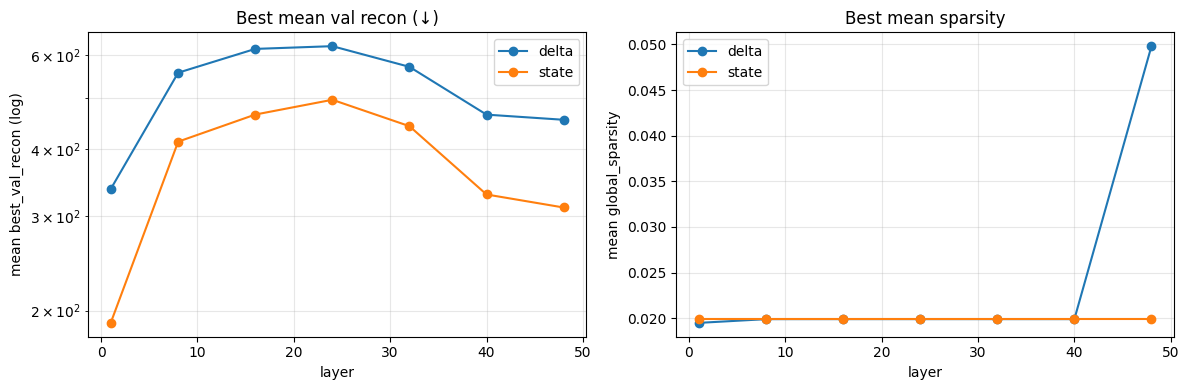

In [35]:
# 5) layer 方向の傾向（参考: raw recon / density）
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for sig, sub in best_hyper.groupby("signal"):
    axes[0].plot(sub["layer"], sub["mean_val_recon"], marker="o", label=sig)
axes[0].set_yscale("log")
axes[0].set_title("Best mean val recon (↓)")
axes[0].set_xlabel("layer")
axes[0].set_ylabel("mean best_val_recon (log)")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

for sig, sub in best_hyper.groupby("signal"):
    axes[1].plot(sub["layer"], sub["mean_sparsity"], marker="o", label=sig)
axes[1].set_title("Best mean sparsity")
axes[1].set_xlabel("layer")
axes[1].set_ylabel("mean global_sparsity")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


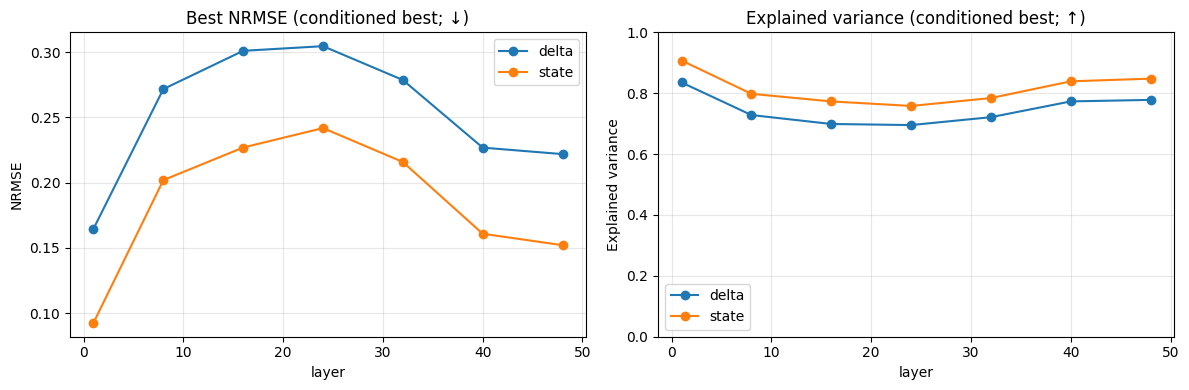

,layer,signal,nrmse,explained_var,l0_est,mean_sparsity,cv_nrmse,best_stable,best_fallback,hidden_factor,k_frac,l1_lambda,eq_alpha
35,1,delta,0.164706,0.835294,159.618795,0.019485,0.002808,True,False,4,0.02,0.0010,0.010
197,8,delta,0.271767,0.728233,162.974767,0.019894,0.002357,True,False,4,0.02,0.0010,0.010
353,16,delta,0.301087,0.698913,163.000000,0.019897,0.000801,True,False,4,0.02,0.0000,0.010
521,24,delta,0.304644,0.695356,163.000000,0.019897,0.000617,True,False,4,0.02,0.0010,0.010
678,32,delta,0.278719,0.721281,163.000000,0.019897,0.001274,True,False,4,0.02,0.0001,0.000
843,40,delta,0.226904,0.773096,163.000000,0.019897,0.001521,True,False,4,0.02,0.0010,0.000
984,48,delta,0.221931,0.778069,204.000000,0.049805,0.001983,True,False,2,0.05,0.0001,0.000
116,1,state,0.092616,0.907384,163.000000,0.019897,0.001734,True,False,4,0.02,0.0010,0.010
278,8,state,0.202013,0.797987,163.000000,0.019897,0.004097,True,False,4,0.02,0.0010,0.010
437,16,state,0.226979,0.773021,163.000000,0.019897,0.002008,True,False,4,0.02,0.0001,0.010


In [36]:
# 5.x) layer 方向トレンド（Var(h) 正規化後）
# 層比較は NRMSE / explained variance に統一（raw は直前セルを参考）

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for sig, sub in best_hyper.groupby("signal"):
    axes[0].plot(sub["layer"], sub["nrmse"], marker="o", label=sig)
axes[0].set_title("Best NRMSE (conditioned best; ↓)")
axes[0].set_xlabel("layer")
axes[0].set_ylabel("NRMSE")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for sig, sub in best_hyper.groupby("signal"):
    axes[1].plot(sub["layer"], sub["explained_var"], marker="o", label=sig)
axes[1].set_title("Explained variance (conditioned best; ↑)")
axes[1].set_xlabel("layer")
axes[1].set_ylabel("Explained variance")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# best の条件（fixed L0/density）と seed 安定性も一緒に確認
display(
    best_hyper[
        [
            "layer",
            "signal",
            "nrmse",
            "explained_var",
            "l0_est",
            "mean_sparsity",
            "cv_nrmse",
            "best_stable",
            "best_fallback",
            "hidden_factor",
            "k_frac",
            "l1_lambda",
            "eq_alpha",
        ]
    ].sort_values(["signal", "layer"], kind="stable")
)


In [37]:
# 5.z) 解析に使う層の候補（NRMSE + tradeoff + seed安定）

# layer×signal ごとに
# - (1) fixed-L0/density で選んだ best の NRMSE
# - (2) 低L0でも良いか（tradeoff の緩さ）
# - (3) best の seed安定性(CV)
# をまとめてランキングする

L0_LOW = 100
L0_HIGH = 400
CV_MAX = CV_SEED_THRESH  # さっきのトリム閾値に合わせる

rows = []
for (layer, signal), sub in agg.groupby(["layer", "signal"], sort=True):
    sub_ok = sub[(sub["n_runs"] >= MIN_SEEDS_KEEP) & (sub["cv_nrmse"] <= CV_MAX)]
    if len(sub_ok) == 0:
        continue

    nrmse_low = float(sub_ok[sub_ok["l0_est"] <= L0_LOW]["nrmse"].min()) if np.any(sub_ok["l0_est"] <= L0_LOW) else float("nan")
    nrmse_high = float(sub_ok[sub_ok["l0_est"] <= L0_HIGH]["nrmse"].min()) if np.any(sub_ok["l0_est"] <= L0_HIGH) else float("nan")
    tradeoff_ratio = float(nrmse_low / (nrmse_high + 1e-12)) if np.isfinite(nrmse_low) and np.isfinite(nrmse_high) else float("nan")

    bh = best_hyper[(best_hyper.layer == layer) & (best_hyper.signal == signal)]
    if len(bh) == 0:
        continue
    bh = bh.iloc[0]

    rows.append(
        {
            "layer": int(layer),
            "signal": signal,
            "best_nrmse": float(bh["nrmse"]),
            "best_l0": float(bh["l0_est"]),
            "best_cv": float(bh["cv_nrmse"]),
            "tradeoff_ratio(L0<=low / L0<=high)": tradeoff_ratio,
            "nrmse_low(L0<=low)": nrmse_low,
            "nrmse_high(L0<=high)": nrmse_high,
            "best_fallback": bool(bh.get("best_fallback", False)),
        }
    )

sel = pd.DataFrame(rows)


def z(x: pd.Series) -> pd.Series:
    return (x - x.mean()) / (x.std(ddof=0) + 1e-12)


# score: best_nrmse (good) + tradeoff_ratio (close to 1 is good) + best_cv (small is good)
sel["z_best_nrmse"] = sel.groupby("signal")["best_nrmse"].transform(z)
sel["z_tradeoff"] = sel.groupby("signal")["tradeoff_ratio(L0<=low / L0<=high)"].transform(z)
sel["z_best_cv"] = sel.groupby("signal")["best_cv"].transform(z)
sel["layer_score"] = sel["z_best_nrmse"] + 0.5 * sel["z_tradeoff"] + 0.5 * sel["z_best_cv"]

print(f"L0_LOW={L0_LOW}, L0_HIGH={L0_HIGH}, CV_MAX={CV_MAX}, best_mode={BEST_MODE}")
display(sel.sort_values(["signal", "layer_score"], kind="stable"))

print("\n--- top layers per signal ---")
display(sel.sort_values(["signal", "layer_score"], kind="stable").groupby("signal", as_index=False).head(3))


L0_LOW=100, L0_HIGH=400, CV_MAX=0.02, best_mode=fixed_l0


,layer,signal,best_nrmse,best_l0,best_cv,tradeoff_ratio(L0<=low / L0<=high),nrmse_low(L0<=low),nrmse_high(L0<=high),best_fallback,z_best_nrmse,z_tradeoff,z_best_cv,layer_score
10,40,delta,0.226904,163.000000,0.001521,1.831793,0.306676,0.167418,False,-0.551964,-0.559184,-0.136861,-0.899986
12,48,delta,0.221931,204.000000,0.001983,1.849499,0.293564,0.158726,False,-0.657867,-0.511576,0.482704,-0.672303
8,32,delta,0.278719,163.000000,0.001274,1.802253,0.371667,0.206223,False,0.551490,-0.638608,-0.468489,-0.002058
0,1,delta,0.164706,159.618795,0.002808,2.904264,0.268536,0.092463,False,-1.876514,2.324428,1.588960,0.080181
6,24,delta,0.304644,163.000000,0.000617,1.819073,0.404622,0.222433,False,1.103578,-0.593385,-1.348694,0.132539
4,16,delta,0.301087,163.000000,0.000801,1.900999,0.405540,0.213330,False,1.027840,-0.373105,-1.102385,0.290095
2,8,delta,0.271767,162.974767,0.002357,2.170467,0.385288,0.177514,False,0.403437,0.351429,0.984764,1.071533
11,40,state,0.160918,163.000000,0.000506,1.934183,0.224155,0.115891,False,-0.489533,-0.508720,-0.834306,-1.161046
13,48,state,0.152150,163.000000,0.001037,1.935470,0.208409,0.107679,False,-0.670476,-0.507064,-0.395828,-1.121922
1,1,state,0.092616,163.000000,0.001734,4.176825,0.178945,0.042842,False,-1.899101,2.377334,0.180166,-0.620351



--- top layers per signal ---


,layer,signal,best_nrmse,best_l0,best_cv,tradeoff_ratio(L0<=low / L0<=high),nrmse_low(L0<=low),nrmse_high(L0<=high),best_fallback,z_best_nrmse,z_tradeoff,z_best_cv,layer_score
10,40,delta,0.226904,163.0,0.001521,1.831793,0.306676,0.167418,False,-0.551964,-0.559184,-0.136861,-0.899986
12,48,delta,0.221931,204.0,0.001983,1.849499,0.293564,0.158726,False,-0.657867,-0.511576,0.482704,-0.672303
8,32,delta,0.278719,163.0,0.001274,1.802253,0.371667,0.206223,False,0.551490,-0.638608,-0.468489,-0.002058
11,40,state,0.160918,163.0,0.000506,1.934183,0.224155,0.115891,False,-0.489533,-0.508720,-0.834306,-1.161046
13,48,state,0.152150,163.0,0.001037,1.935470,0.208409,0.107679,False,-0.670476,-0.507064,-0.395828,-1.121922
1,1,state,0.092616,163.0,0.001734,4.176825,0.178945,0.042842,False,-1.899101,2.377334,0.180166,-0.620351


stable-first (CV_MAX=0.02, MIN_SEEDS=2), band=±20% (fallback to nearest if empty)
=== best NRMSE at fixed L0 (smaller is better) ===


target_l0         200       500       1000
signal layer                              
delta  1      0.222640  0.175089  0.063876
       8      0.271767  0.201836  0.117245
       16     0.301087  0.216874  0.139755
       24     0.304644  0.207120  0.142110
       32     0.278719  0.188514  0.122788
       40     0.226904  0.155429  0.099670
       48     0.221931  0.148204  0.092680
state  1      0.092616  0.062220  0.027159
       8      0.202013  0.145948  0.079478
       16     0.226979  0.173745  0.109496
       24     0.241883  0.180992  0.119817
       32     0.215913  0.159350  0.107065
       40     0.160918  0.119511  0.080579
       48     0.152150  0.107682  0.070588

=== picked L0 (actual) ===


target_l0           200         500         1000
signal layer                                    
delta  1      200.138550  405.670654  804.306905
       8      162.974767  408.955638  818.848409
       16     163.000000  409.000000  818.976644
       24     163.000000  409.000000  819.000000
       32     163.000000  409.000000  819.000000
       40     163.000000  409.000000  819.000000
       48     204.000000  409.000000  819.000000
state  1      163.000000  409.000000  819.000000
       8      163.000000  409.000000  819.000000
       16     163.000000  409.000000  819.000000
       24     163.000000  409.000000  819.000000
       32     163.000000  409.000000  819.000000
       40     163.000000  409.000000  819.000000
       48     163.000000  409.000000  819.000000

=== used fallback (True means no point in the band) ===


target_l0      200    500    1000
signal layer                     
delta  1      False  False  False
       8      False  False  False
       16     False  False  False
       24     False  False  False
       32     False  False  False
       40     False  False  False
       48     False  False  False
state  1      False  False  False
       8      False  False  False
       16     False  False  False
       24     False  False  False
       32     False  False  False
       40     False  False  False
       48     False  False  False


=== Best NRMSE @ L0≈200 (layer×signal) ===


signal,delta,state
layer,,
1,0.222640,0.092616
8,0.271767,0.202013
16,0.301087,0.226979
24,0.304644,0.241883
32,0.278719,0.215913
40,0.226904,0.160918
48,0.221931,0.152150


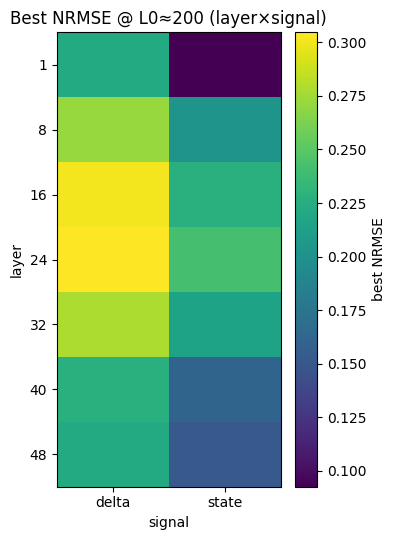


=== Best NRMSE @ L0≈500 (layer×signal) ===


signal,delta,state
layer,,
1,0.175089,0.062220
8,0.201836,0.145948
16,0.216874,0.173745
24,0.207120,0.180992
32,0.188514,0.159350
40,0.155429,0.119511
48,0.148204,0.107682


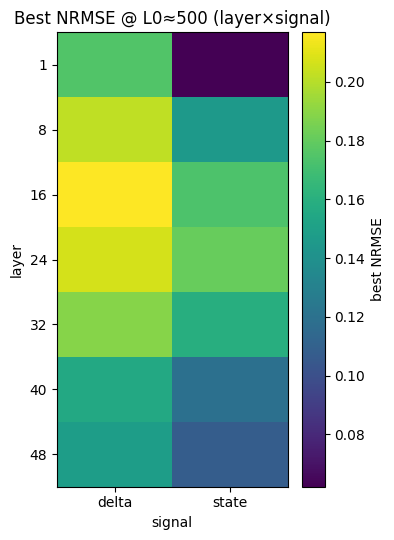


=== Best NRMSE @ L0≈1000 (layer×signal) ===


signal,delta,state
layer,,
1,0.063876,0.027159
8,0.117245,0.079478
16,0.139755,0.109496
24,0.142110,0.119817
32,0.122788,0.107065
40,0.099670,0.080579
48,0.092680,0.070588


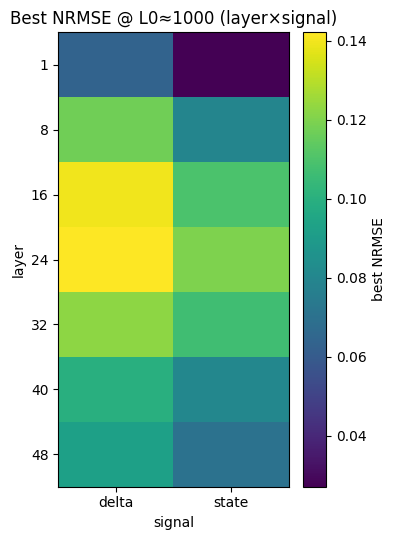

In [38]:
# 5.w) 固定L0ごとの最良NRMSE（layer×signal）

# 例: L0≈200/500/1000 で達成できる最良 NRMSE を layer×(state/delta) で比較
# ※ grid が離散なので、(1±tol) の帯域で拾い、空なら最近傍へ fallback します。

TARGET_L0S = [200, 500, 1000]
L0_TOL_FRAC = 0.20   # ±20%
TOPK_NEAREST = 12

CV_MAX = CV_SEED_THRESH if "CV_SEED_THRESH" in globals() else 0.02
MIN_SEEDS = MIN_SEEDS_KEEP if "MIN_SEEDS_KEEP" in globals() else 2

base = agg.copy()

# 必要な列が無ければ付与
if "cv_nrmse" not in base.columns:
    base["cv_nrmse"] = base["std_val_recon"] / (base["mean_val_recon"] + 1e-12)

if "l0_est" not in base.columns:
    base["dict_dim"] = (base["input_dim"] * base["hidden_factor"]).astype(int)
    base["l0_est"] = base["mean_sparsity"] * base["dict_dim"]

if "hp_name" not in base.columns:
    if "hp_name_from_params" not in globals():
        def hp_name_from_params(hidden_factor, k_frac, l1_lambda, eq_alpha) -> str:
            def fmt(x: float) -> str:
                s = f"{float(x)}".replace("-", "n")
                return s.replace(".", "p")

            return f"hf{int(hidden_factor)}_k{fmt(k_frac)}_l1{fmt(l1_lambda)}_eq{fmt(eq_alpha)}"

    base = base.copy()
    base["hp_name"] = base.apply(
        lambda r: hp_name_from_params(r["hidden_factor"], r["k_frac"], r["l1_lambda"], r["eq_alpha"]),
        axis=1,
    )

rows = []
for target in TARGET_L0S:
    lo = target * (1.0 - L0_TOL_FRAC)
    hi = target * (1.0 + L0_TOL_FRAC)

    for (layer, signal), g_all in base.groupby(["layer", "signal"], sort=True):
        g_stable = g_all[(g_all["n_runs"] >= MIN_SEEDS) & (g_all["cv_nrmse"] <= CV_MAX)]
        used_unstable = len(g_stable) == 0
        g = g_stable if len(g_stable) else g_all

        cand = g[(g["l0_est"] >= lo) & (g["l0_est"] <= hi)]
        used_range_fallback = False
        if cand.empty:
            used_range_fallback = True
            cand = g.assign(_dist=(g["l0_est"] - target).abs()).sort_values("_dist", kind="stable").head(TOPK_NEAREST)

        best = cand.loc[cand["nrmse"].astype(float).idxmin()].copy()

        rows.append(
            {
                "layer": int(layer),
                "signal": signal,
                "target_l0": int(target),
                "band_lo": float(lo),
                "band_hi": float(hi),
                "picked_l0": float(best["l0_est"]),
                "best_nrmse": float(best["nrmse"]),
                "best_explained_var": float(best["explained_var"]),
                "best_hp": str(best.get("hp_name", "")),
                "best_cv": float(best.get("cv_nrmse", np.nan)),
                "best_n_runs": int(best.get("n_runs", 0)),
                "used_unstable": bool(used_unstable),
                "used_range_fallback": bool(used_range_fallback),
            }
        )

fixed_l0 = pd.DataFrame(rows).sort_values(["signal", "layer", "target_l0"], kind="stable")

print(f"stable-first (CV_MAX={CV_MAX}, MIN_SEEDS={MIN_SEEDS}), band=±{int(L0_TOL_FRAC*100)}% (fallback to nearest if empty)")

# 表: layer×signal を行、target_L0 を列（全体俯瞰）
pivot_nrmse = fixed_l0.pivot(index=["signal", "layer"], columns="target_l0", values="best_nrmse")
pivot_l0 = fixed_l0.pivot(index=["signal", "layer"], columns="target_l0", values="picked_l0")
pivot_flags = fixed_l0.pivot(index=["signal", "layer"], columns="target_l0", values="used_range_fallback")

print("=== best NRMSE at fixed L0 (smaller is better) ===")
display(pivot_nrmse)
print("=== picked L0 (actual) ===")
display(pivot_l0)
print("=== used fallback (True means no point in the band) ===")
display(pivot_flags)

# target L0 ごとに layer×(state/delta) を出す（依頼の形）
for target in TARGET_L0S:
    mat = (
        fixed_l0[fixed_l0.target_l0 == target]
        .pivot(index="layer", columns="signal", values="best_nrmse")
        .sort_index()
    )
    print()
    print(f"=== Best NRMSE @ L0≈{target} (layer×signal) ===")
    display(mat)

    plt.figure(figsize=(4, 0.5 * len(mat) + 2))
    if HAS_SEABORN:
        sns.heatmap(mat, annot=True, fmt=".3g", cmap="viridis", cbar_kws={"label": "best NRMSE"})
    else:
        im = plt.imshow(mat.values, cmap="viridis", aspect="auto")
        plt.colorbar(im, label="best NRMSE")
        plt.xticks(range(len(mat.columns)), [str(x) for x in mat.columns])
        plt.yticks(range(len(mat.index)), [str(x) for x in mat.index])

    plt.title(f"Best NRMSE @ L0≈{target} (layer×signal)")
    plt.xlabel("signal")
    plt.ylabel("layer")
    plt.tight_layout()
    plt.show()


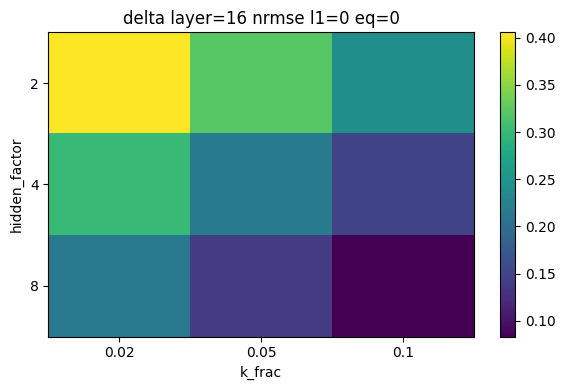

k_frac,0.02,0.05,0.10
hidden_factor,,,
2,0.405576,0.322377,0.244438
4,0.301105,0.216942,0.149307
8,0.213377,0.139833,0.083363


In [39]:
# 6) 2D heatmap（hidden_factor × k_frac）: l1/eq を固定して見る
def plot_heatmap(
    df_agg: pd.DataFrame,
    layer: int,
    signal: str,
    metric: str = "nrmse",
    l1_lambda: float | None = None,
    eq_alpha: float | None = None,
    annot: bool = True,
):
    sub = df_agg[(df_agg["layer"] == layer) & (df_agg["signal"] == signal)]
    if l1_lambda is not None:
        sub = sub[np.isclose(sub["l1_lambda"], l1_lambda)]
    if eq_alpha is not None:
        sub = sub[np.isclose(sub["eq_alpha"], eq_alpha)]
    if sub.empty:
        raise ValueError("No rows after filtering. Check layer/signal/l1/eq.")

    pivot = sub.pivot(index="hidden_factor", columns="k_frac", values=metric).sort_index()

    plt.figure(figsize=(6, 4))
    if HAS_SEABORN:
        sns.heatmap(pivot, annot=annot, fmt=".2g", cmap="viridis")
    else:
        plt.imshow(pivot.values, cmap="viridis", aspect="auto")
        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.yticks(range(len(pivot.index)), pivot.index)
        plt.colorbar()

    title = f"{signal} layer={layer} {metric}"
    if l1_lambda is not None:
        title += f" l1={l1_lambda:g}"
    if eq_alpha is not None:
        title += f" eq={eq_alpha:g}"
    plt.title(title)
    plt.xlabel("k_frac")
    plt.ylabel("hidden_factor")
    plt.tight_layout()
    plt.show()
    return pivot


# 例: layer=16 / delta の NRMSE heatmap
LAYER = 16
SIGNAL = "delta"
L1 = 0.0
EQ = 0.0
plot_heatmap(agg, layer=LAYER, signal=SIGNAL, metric="nrmse", l1_lambda=L1, eq_alpha=EQ)


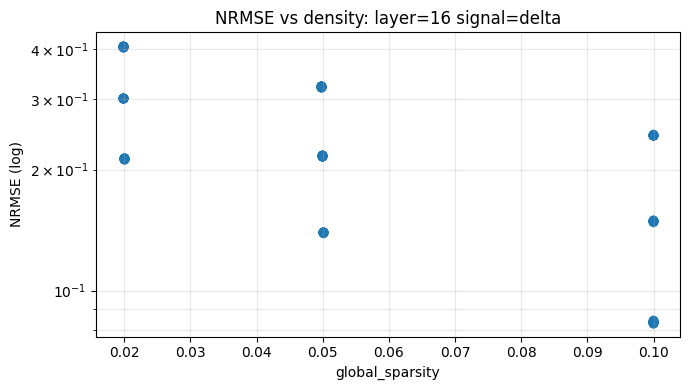

In [40]:
# 7) NRMSE vs density の散布図（run 単位）
def plot_tradeoff(df_runs: pd.DataFrame, layer: int, signal: str, hue: str = "k_frac"):
    sub = df_runs[(df_runs["layer"] == layer) & (df_runs["signal"] == signal)]
    if sub.empty:
        raise ValueError("No rows for layer/signal")

    plt.figure(figsize=(7, 4))
    if HAS_SEABORN and hue in sub.columns:
        sns.scatterplot(
            data=sub,
            x="detailed_stats.global_sparsity",
            y="nrmse",
            hue=hue,
            style="hidden_factor",
            alpha=0.6,
        )
    else:
        plt.scatter(sub["detailed_stats.global_sparsity"], sub["nrmse"], alpha=0.5)

    plt.yscale("log")
    plt.xlabel("global_sparsity")
    plt.ylabel("NRMSE (log)")
    plt.title(f"NRMSE vs density: layer={layer} signal={signal}")
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_tradeoff(all_df, layer=LAYER, signal=SIGNAL)


run_dir: /raid/sasaki/runs/202512101038/mamba_1.4b_hf/layer_1/delta/grid/hf4_k0p02_l10p001_eq0p01_seed0
run_name: hf4_k0p02_l10p001_eq0p01_seed0 best_val_recon: 336.347584890625

[detailed_stats] numeric (sorted)


/tmp/ipykernel_479/2497837754.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  metrics = torch.load(metrics_path, map_location="cpu") if metrics_path.exists() else None


sample_size           20000.000000
recon_error_mean        333.570496
active_median           163.000000
active_p95              163.000000
recon_error_median      162.522644
active_mean             159.860992
mean_firing               0.019514
global_sparsity           0.019514
median_firing             0.015300
dead_rate                 0.000000
dtype: float64


[detailed_stats] list items (preview)


,len,last
code_pca_cumvar,256.0,1.0
input_pca_cumvar,256.0,1.0


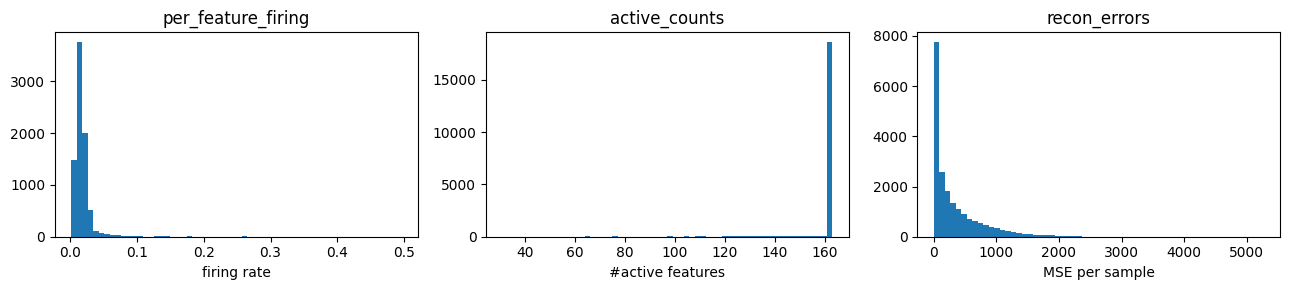

,feature,firing
0,4592,0.49550
1,3287,0.45865
2,7390,0.42260
3,2135,0.40710
4,1807,0.40325
5,1083,0.39315
6,5709,0.38625
7,27,0.38495
8,2789,0.36940
9,3543,0.36700


In [41]:
# 8) ベスト run の artifact を覗く（summary.json / sample_metrics.pt）
import torch


def load_run_artifacts(checkpoint_path: str):
    ckpt_path = Path(checkpoint_path)
    run_dir = ckpt_path.parent
    summary_path = run_dir / "summary.json"
    metrics_path = run_dir / "sample_metrics.pt"
    summary = json.loads(summary_path.read_text()) if summary_path.exists() else None
    metrics = torch.load(metrics_path, map_location="cpu") if metrics_path.exists() else None
    return run_dir, summary, metrics


# ここを差し替えると任意の (layer,signal) を見れます
row = best_run.iloc[0]
run_dir, summary, metrics = load_run_artifacts(row["checkpoint"])
print("run_dir:", run_dir)
print("run_name:", summary["run_name"], "best_val_recon:", summary["best_val_recon"])
# detailed_stats は list を含むので、そのまま sort すると TypeError になる
_dstats = summary.get("detailed_stats", {}) if summary else {}
_s = pd.Series(_dstats)
_num = pd.to_numeric(_s, errors="coerce").dropna().sort_values(ascending=False)
print("\n[detailed_stats] numeric (sorted)")
display(_num)

_list_items = {k: v for k, v in _dstats.items() if isinstance(v, list)}
if _list_items:
    _list_summary = {}
    for k, v in _list_items.items():
        last = v[-1] if len(v) else None
        _list_summary[k] = {"len": len(v), "last": last}
    print("\n[detailed_stats] list items (preview)")
    display(pd.DataFrame(_list_summary).T)


if metrics is not None:
    per_feature = metrics["per_feature_firing"].float().numpy()
    active = metrics["active_counts"].float().numpy()
    recon_err = metrics["recon_errors"].float().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(13, 3))
    axes[0].hist(per_feature, bins=60)
    axes[0].set_title("per_feature_firing")
    axes[0].set_xlabel("firing rate")

    axes[1].hist(active, bins=60)
    axes[1].set_title("active_counts")
    axes[1].set_xlabel("#active features")

    axes[2].hist(recon_err, bins=60)
    axes[2].set_title("recon_errors")
    axes[2].set_xlabel("MSE per sample")

    plt.tight_layout()
    plt.show()

    top = np.argsort(-per_feature)[:20]
    display(pd.DataFrame({"feature": top, "firing": per_feature[top]}))


,layer,signal,nrmse,std_nrmse,cv_nrmse,hidden_factor,k_frac,l1_lambda,eq_alpha
78,1,delta,0.043013,0.000092,0.002130,8,0.1,0.0010,0.00
240,8,delta,0.074583,0.000121,0.001627,8,0.1,0.0010,0.00
402,16,delta,0.083338,0.000214,0.002568,8,0.1,0.0010,0.00
564,24,delta,0.083993,0.000236,0.002807,8,0.1,0.0010,0.00
728,32,delta,0.078662,0.000329,0.004177,8,0.1,0.0010,0.01
890,40,delta,0.063287,0.000120,0.001903,8,0.1,0.0010,0.01
1052,48,delta,0.062742,0.000439,0.006998,8,0.1,0.0010,0.01
161,1,state,0.018227,0.000038,0.002097,8,0.1,0.0010,0.01
321,8,state,0.051509,0.000148,0.002882,8,0.1,0.0010,0.00
480,16,state,0.071111,0.000163,0.002297,8,0.1,0.0001,0.00


--- flagged: CV > 0.02 (at best HP) ---


,layer,signal,cv_nrmse,nrmse,hidden_factor,k_frac


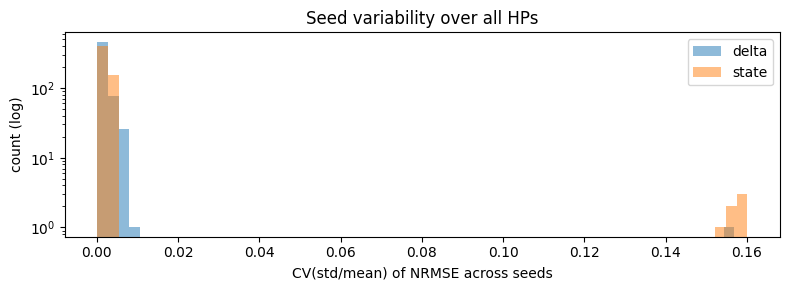

In [42]:
# 10.1b) Seed 安定性の定量化（CV / outlier をフラグ）
# HP ごとの mean±std と、CV = std/mean を layer×signal で眺める（NRMSE で統一）

seed_var = agg.copy()

# std_val_recon は raw(SSE) なので、NRMSE の std に直す
seed_var["std_nrmse"] = seed_var["std_val_recon"] / seed_var["var_norm_sum"]
seed_var["cv_nrmse"] = seed_var["std_nrmse"] / (seed_var["nrmse"] + 1e-12)

# best HP（NRMSE 最小）における CV
best_cv = (
    seed_var.sort_values(["layer", "signal", "nrmse"], kind="stable")
    .groupby(["layer", "signal"], as_index=False)
    .head(1)
    .sort_values(["signal", "layer"], kind="stable")
)

display(
    best_cv[
        [
            "layer",
            "signal",
            "nrmse",
            "std_nrmse",
            "cv_nrmse",
            "hidden_factor",
            "k_frac",
            "l1_lambda",
            "eq_alpha",
        ]
    ]
)

# CV が大きい layer/signal をフラグ
CV_THRESH = 0.02
print(f"--- flagged: CV > {CV_THRESH} (at best HP) ---")
display(best_cv[best_cv["cv_nrmse"] > CV_THRESH][["layer", "signal", "cv_nrmse", "nrmse", "hidden_factor", "k_frac"]])

# HP 全体の CV 分布（signal 別）
plt.figure(figsize=(8, 3))
for sig, g in seed_var.groupby("signal"):
    plt.hist(g["cv_nrmse"].dropna(), bins=60, alpha=0.5, label=sig)
plt.yscale("log")
plt.xlabel("CV(std/mean) of NRMSE across seeds")
plt.ylabel("count (log)")
plt.title("Seed variability over all HPs")
plt.legend()
plt.tight_layout()
plt.show()


In [43]:
# 10.1c) outlier run 検出（同一HPで seed 間に極端差）
# seed 間で挙動が割れる（学習崩壊/ログ混入/不安定）run を早期発見
# NRMSE で統一して検出する（raw recon は参考）

base = all_df_raw if "all_df_raw" in globals() else all_df

if "hp_name_from_run" not in globals():
    def hp_name_from_run(run_name: str) -> str:
        return str(run_name).rsplit("_seed", 1)[0]

# hp_name は 10.0 helper で作っている想定
if "hp_name" not in base.columns:
    base = base.copy()
    base["hp_name"] = base["run_name"].map(hp_name_from_run)

runs = base.copy()

# nrmse が無ければ付与
if "nrmse" not in runs.columns:
    merge_cols = ["layer", "signal", "input_dim", "var_norm_sum"]
    if "var_norm_sum" not in runs.columns:
        runs = runs.merge(layer_stats_df[merge_cols], on=["layer", "signal"], how="left")
    runs = _add_norm_cols(runs)

runs["density_gap"] = runs["detailed_stats.global_sparsity"].astype(float) - runs["k_frac"].astype(float)

hp_seed = (
    runs.groupby(["layer", "signal", "hp_name"], sort=True)
    .agg(
        n_seeds=("seed", "nunique"),
        nrmse_mean=("nrmse", "mean"),
        nrmse_std=("nrmse", "std"),
        nrmse_min=("nrmse", "min"),
        nrmse_max=("nrmse", "max"),
        density_mean=("detailed_stats.global_sparsity", "mean"),
        density_std=("detailed_stats.global_sparsity", "std"),
        density_gap_abs_max=("density_gap", lambda x: float(np.max(np.abs(x)))),
    )
    .reset_index()
)

hp_seed["nrmse_cv"] = hp_seed["nrmse_std"] / (hp_seed["nrmse_mean"] + 1e-12)
hp_seed["nrmse_ratio"] = hp_seed["nrmse_max"] / (hp_seed["nrmse_min"] + 1e-12)

CV_T = CV_SEED_THRESH if "CV_SEED_THRESH" in globals() else 0.02
RATIO_T = 1.20
GAP_T = 0.01

outliers = hp_seed[
    (hp_seed["n_seeds"] >= 2)
    & (
        (hp_seed["nrmse_cv"] > CV_T)
        | (hp_seed["nrmse_ratio"] > RATIO_T)
        | (hp_seed["density_gap_abs_max"] > GAP_T)
    )
].copy()

print(f"flagged groups: {len(outliers)} / {len(hp_seed)} (CV_T={CV_T}, RATIO_T={RATIO_T}, GAP_T={GAP_T})")
display(outliers.sort_values(["nrmse_cv", "nrmse_ratio"], ascending=[False, False], kind="stable").head(30))

# 上位だけ詳細表示（必要なら TOPN を増やす）
TOPN = 5
for _, r in outliers.sort_values(["nrmse_cv"], ascending=False, kind="stable").head(TOPN).iterrows():
    layer = int(r["layer"])
    signal = r["signal"]
    hp = r["hp_name"]
    sub = runs[(runs.layer == layer) & (runs.signal == signal) & (runs.hp_name == hp)][
        [
            "seed",
            "nrmse",
            "best_val_recon",
            "detailed_stats.global_sparsity",
            "detailed_stats.dead_rate",
            "checkpoint",
        ]
    ].sort_values("seed", kind="stable")
    print(f"layer={layer} signal={signal} hp={hp} ---")
    display(sub)

flagged groups: 12 / 1134 (CV_T=0.02, RATIO_T=1.2, GAP_T=0.01)


,layer,signal,hp_name,n_seeds,nrmse_mean,nrmse_std,nrmse_min,nrmse_max,density_mean,density_std,density_gap_abs_max,nrmse_cv,nrmse_ratio
1051,48,delta,hf8_k0p1_l10p0_eq0p001,3,0.068644,0.009964,0.062514,0.080141,0.099975,3.850107e-07,0.000025,0.145156,1.281968
1132,48,state,hf8_k0p1_l10p0_eq0p001,3,0.053385,0.007659,0.048955,0.062229,0.099976,0.000000e+00,0.000024,0.143459,1.271144
1130,48,state,hf8_k0p1_l10p001_eq0p01,3,0.053354,0.007050,0.049172,0.061494,0.099976,0.000000e+00,0.000024,0.132141,1.250604
1050,48,delta,hf8_k0p1_l10p0_eq0p0,3,0.068284,0.008961,0.062857,0.078628,0.099975,4.301595e-07,0.000025,0.131232,1.250888
1126,48,state,hf8_k0p1_l10p0001_eq0p001,3,0.057320,0.007432,0.048753,0.062044,0.099976,7.450581e-09,0.000024,0.129664,1.272628
1046,48,delta,hf8_k0p1_l10p0001_eq0p01,3,0.074050,0.009586,0.063020,0.080372,0.099975,9.399058e-07,0.000026,0.129451,1.275326
1128,48,state,hf8_k0p1_l10p001_eq0p0,3,0.052721,0.006753,0.048691,0.060517,0.099976,8.603189e-09,0.000024,0.128090,1.242887
1131,48,state,hf8_k0p1_l10p0_eq0p0,3,0.057323,0.007295,0.048913,0.061950,0.099976,4.301595e-09,0.000024,0.127270,1.266549
1129,48,state,hf8_k0p1_l10p001_eq0p001,3,0.057401,0.007289,0.048987,0.061780,0.099976,7.450581e-09,0.000024,0.126976,1.261151
1125,48,state,hf8_k0p1_l10p0001_eq0p0,3,0.057125,0.007207,0.048803,0.061300,0.099976,0.000000e+00,0.000024,0.126159,1.256080


layer=48 signal=delta hp=hf8_k0p1_l10p0_eq0p001 ---


,seed,nrmse,best_val_recon,detailed_stats.global_sparsity,detailed_stats.dead_rate,checkpoint
3135,0,0.063276,129.589108,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
3136,1,0.062514,128.027157,0.099975,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
3137,2,0.080141,164.126758,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...


layer=48 signal=state hp=hf8_k0p1_l10p0_eq0p001 ---


...

,seed,nrmse,best_val_recon,detailed_stats.global_sparsity,detailed_stats.dead_rate,checkpoint
3399,0,0.049172,100.702856,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
3400,1,0.061494,125.939431,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
3401,2,0.049397,101.164565,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...


layer=48 signal=delta hp=hf8_k0p1_l10p0_eq0p0 ---


,seed,nrmse,best_val_recon,detailed_stats.global_sparsity,detailed_stats.dead_rate,checkpoint
3132,0,0.078628,161.028186,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
3133,1,0.062857,128.731086,0.099975,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
3134,2,0.063368,129.777007,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...


layer=48 signal=state hp=hf8_k0p1_l10p0001_eq0p001 ---


,seed,nrmse,best_val_recon,detailed_stats.global_sparsity,detailed_stats.dead_rate,checkpoint
3387,0,0.061163,125.259922,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
3388,1,0.048753,99.845086,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...
3389,2,0.062044,127.065624,0.099976,0.0,/raid/sasaki/runs/202512101038/mamba_1.4b_hf/l...


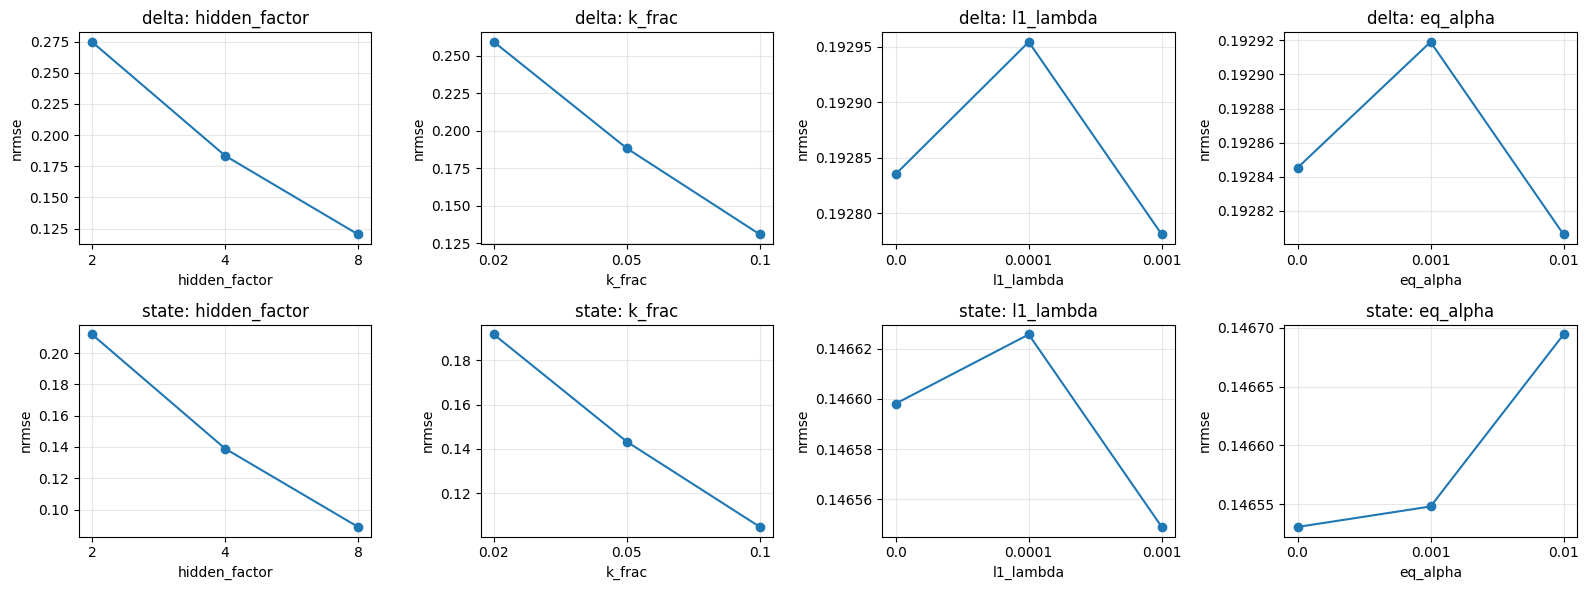

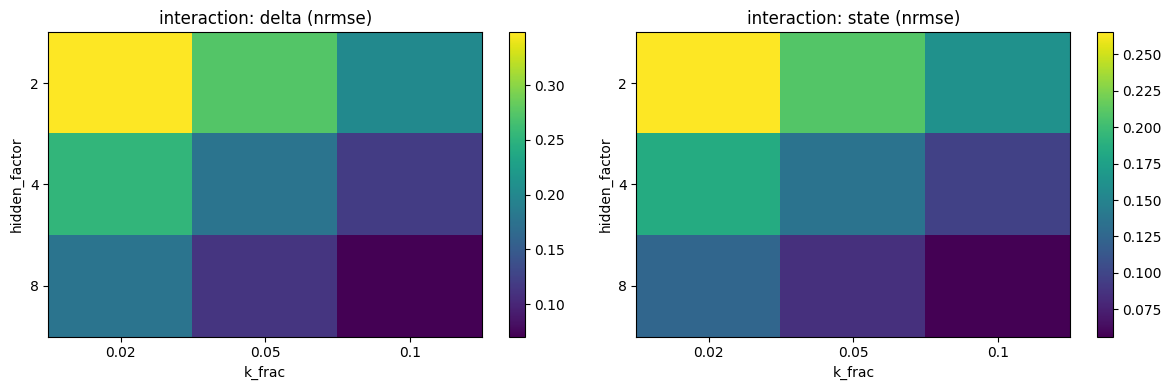

In [44]:
# 10.2b) HP 感度を全域で可視化（main effects / interaction）
# main effect: 各軸で平均化して傾向を見る
# interaction: (hidden_factor × k_frac) を他軸で平均して heatmap

METRIC = "nrmse"  # "mean_val_recon" / "explained_var" などに差し替え可
params = ["hidden_factor", "k_frac", "l1_lambda", "eq_alpha"]

signals = sorted(agg["signal"].unique())
fig, axes = plt.subplots(len(signals), len(params), figsize=(4 * len(params), 3 * len(signals)), squeeze=False)

for i, sig in enumerate(signals):
    sub = agg[agg.signal == sig].copy()
    for j, p in enumerate(params):
        eff = sub.groupby(p, sort=True)[METRIC].mean().reset_index().sort_values(p, kind="stable")
        ax = axes[i][j]
        ax.plot(eff[p].astype(str), eff[METRIC], marker="o")
        ax.set_title(f"{sig}: {p}")
        ax.set_xlabel(p)
        ax.set_ylabel(METRIC)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# interaction heatmap (signal 別)
fig, axes = plt.subplots(1, len(signals), figsize=(6 * len(signals), 4), squeeze=False)
for j, sig in enumerate(signals):
    sub = agg[agg.signal == sig]
    pivot = (
        sub.groupby(["hidden_factor", "k_frac"], sort=True)[METRIC]
        .mean()
        .unstack()
        .sort_index()
    )

    ax = axes[0][j]
    if HAS_SEABORN:
        sns.heatmap(pivot, annot=True, fmt=".3g", cmap="viridis", ax=ax)
    else:
        im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
        ax.figure.colorbar(im, ax=ax)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([str(x) for x in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([str(x) for x in pivot.index])

    ax.set_title(f"interaction: {sig} ({METRIC})")
    ax.set_xlabel("k_frac")
    ax.set_ylabel("hidden_factor")

plt.tight_layout()
plt.show()


,layer,signal,knee_sparsity,knee_nrmse,knee_hp,knee_strength
0,1,delta,0.049091,0.063876,hf8_k0p05_l10p001_eq0p01,0.079484
2,8,delta,0.019951,0.177514,hf8_k0p02_l10p0001_eq0p01,0.332177
4,16,delta,0.019958,0.213330,hf8_k0p02_l10p001_eq0p01,0.285458
6,24,delta,0.019958,0.222433,hf8_k0p02_l10p0001_eq0p0,0.267583
8,32,delta,0.019958,0.206223,hf8_k0p02_l10p001_eq0p001,0.266612
10,40,delta,0.019958,0.167418,hf8_k0p02_l10p0_eq0p0,0.269739
12,48,delta,0.019958,0.158726,hf8_k0p02_l10p0_eq0p001,0.280168
1,1,state,0.019958,0.042842,hf8_k0p02_l10p001_eq0p01,0.441009
3,8,state,0.019958,0.122942,hf8_k0p02_l10p0001_eq0p001,0.358524
5,16,state,0.019958,0.157198,hf8_k0p02_l10p001_eq0p01,0.328652


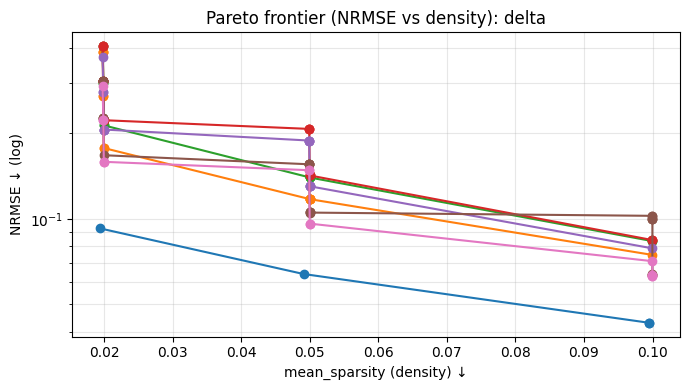

In [45]:
# 10.2) Pareto（NRMSE vs density）: frontier & elbow（knee）を layer ごとに比較
# ここでは metric=nrmse↓ と sparsity=mean_sparsity↓（=よりスパース）を同時に最小化

if "pareto_frontier" not in globals():
    def pareto_frontier(df: pd.DataFrame, x: str, y: str) -> pd.DataFrame:
        sub = df.dropna(subset=[x, y]).sort_values(x, kind="stable")
        best_y = float("inf")
        keep = []
        for _, r in sub.iterrows():
            yy = float(r[y])
            if yy < best_y:
                keep.append(r)
                best_y = yy
        return pd.DataFrame(keep)

if "knee_point" not in globals():
    def knee_point(frontier: pd.DataFrame, x: str, y: str):
        if len(frontier) < 3:
            return (frontier.iloc[0] if len(frontier) else None), float("nan")
        xs = frontier[x].to_numpy(dtype=float)
        ys = np.log(frontier[y].to_numpy(dtype=float))
        x_n = (xs - xs.min()) / (xs.max() - xs.min() + 1e-12)
        y_n = (ys - ys.min()) / (ys.max() - ys.min() + 1e-12)
        x0, y0 = x_n[0], y_n[0]
        x1, y1 = x_n[-1], y_n[-1]
        num = np.abs((y1 - y0) * x_n - (x1 - x0) * y_n + x1 * y0 - y1 * x0)
        den = np.sqrt((y1 - y0) ** 2 + (x1 - x0) ** 2) + 1e-12
        dist = num / den
        i = int(np.argmax(dist))
        return frontier.iloc[i], float(dist[i])


# hp_name が無ければ作る（knee で表示用）
if "hp_name" not in agg.columns:
    if "hp_name_from_params" not in globals():
        def hp_name_from_params(hidden_factor, k_frac, l1_lambda, eq_alpha) -> str:
            def fmt(x: float) -> str:
                s = f"{float(x)}".replace("-", "n")
                return s.replace(".", "p")

            return f"hf{int(hidden_factor)}_k{fmt(k_frac)}_l1{fmt(l1_lambda)}_eq{fmt(eq_alpha)}"

    agg = agg.copy()
    agg["hp_name"] = agg.apply(
        lambda r: hp_name_from_params(r["hidden_factor"], r["k_frac"], r["l1_lambda"], r["eq_alpha"]),
        axis=1,
    )

front_rows = []
knee_rows = []
for (layer, signal), sub in agg.groupby(["layer", "signal"], sort=True):
    f = pareto_frontier(sub, x="mean_sparsity", y="nrmse")
    if f.empty:
        continue
    knee, dist = knee_point(f, x="mean_sparsity", y="nrmse")
    front_rows.append(f.assign(layer=layer, signal=signal, is_frontier=True))
    knee_rows.append(
        {
            "layer": layer,
            "signal": signal,
            "knee_sparsity": float(knee["mean_sparsity"]),
            "knee_nrmse": float(knee["nrmse"]),
            "knee_hp": knee["hp_name"],
            "knee_strength": float(dist),
        }
    )

frontier_df = pd.concat(front_rows, ignore_index=True) if front_rows else pd.DataFrame()
knee_df = pd.DataFrame(knee_rows).sort_values(["signal", "layer"], kind="stable")
display(knee_df)

# 可視化（signal を変えると state/delta 別に見れます）
SIGNAL = "delta"
subf = frontier_df[frontier_df.signal == SIGNAL]
plt.figure(figsize=(7, 4))
if HAS_SEABORN and len(subf):
    sns.lineplot(data=subf, x="mean_sparsity", y="nrmse", hue="layer", marker="o", legend=False)
else:
    for layer, g in subf.groupby("layer"):
        plt.plot(g["mean_sparsity"], g["nrmse"], marker="o", label=f"L{layer}")

plt.yscale("log")
plt.xlabel("mean_sparsity (density) ↓")
plt.ylabel("NRMSE ↓ (log)")
plt.title(f"Pareto frontier (NRMSE vs density): {SIGNAL}")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


Base best @ layer=24 signal=delta:


layer                       24
signal                   delta
hidden_factor                4
k_frac                    0.02
l1_lambda                0.001
eq_alpha                  0.01
n_runs                       3
mean_val_recon       623.90284
std_val_recon         0.385242
cv_nrmse              0.000617
mean_sparsity         0.019897
mean_dead_rate             0.0
mean_firing           0.019897
mean_pca_code_256          1.0
mean_active_mean         163.0
l0_est                   163.0
nrmse                 0.304644
explained_var         0.695356
best_mode             fixed_l0
best_stable               True
best_fallback            False
Name: 521, dtype: object


--- one-axis neighbors (worse first) ---


,changed,mean_val_recon,rel_recon,mean_sparsity,delta_sparsity,mean_dead_rate,delta_dead_rate
0,hidden_factor=2,828.732131,1.328303,0.019775,-0.000122,0.0,0.0
6,eq_alpha=0.0,624.073639,1.000274,0.019897,0.000000,0.0,0.0
7,eq_alpha=0.001,624.048715,1.000234,0.019897,0.000000,0.0,0.0
4,l1_lambda=0.0,623.983210,1.000129,0.019897,0.000000,0.0,0.0
5,l1_lambda=0.0001,623.979326,1.000123,0.019897,0.000000,0.0,0.0
1,hidden_factor=8,455.712436,0.730422,0.019958,0.000061,0.0,0.0
2,k_frac=0.05,424.521744,0.680429,0.049927,0.030029,0.0,0.0
3,k_frac=0.1,291.256675,0.466830,0.099976,0.080078,0.0,0.0


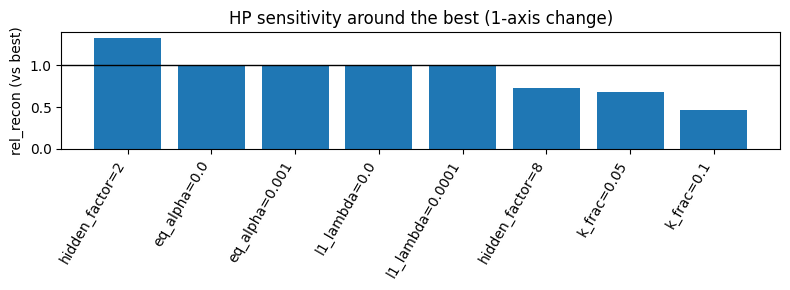

In [46]:
# 10.3) HP感度：ベスト近傍（1軸だけ変化）での劣化が滑らかか/崩壊か

LAYER = 24
SIGNAL = "delta"

best = best_hyper[(best_hyper.layer == LAYER) & (best_hyper.signal == SIGNAL)].iloc[0]
sub = agg[(agg.layer == LAYER) & (agg.signal == SIGNAL)].copy()

params = ["hidden_factor", "k_frac", "l1_lambda", "eq_alpha"]
base_recon = float(best["mean_val_recon"])
base_dead = float(best["mean_dead_rate"])
base_sparse = float(best["mean_sparsity"])

nbr = []
for p in params:
    for v in sorted(sub[p].unique()):
        if p == "hidden_factor":
            same = int(v) == int(best[p])
        else:
            same = bool(np.isclose(float(v), float(best[p])))
        if same:
            continue

        m = (sub["layer"] == LAYER) & (sub["signal"] == SIGNAL)
        for q in params:
            if q == p:
                if q == "hidden_factor":
                    m &= sub[q].astype(int) == int(v)
                else:
                    m &= np.isclose(sub[q].astype(float), float(v))
            else:
                if q == "hidden_factor":
                    m &= sub[q].astype(int) == int(best[q])
                else:
                    m &= np.isclose(sub[q].astype(float), float(best[q]))

        cand = sub[m]
        if cand.empty:
            continue
        row = cand.iloc[0]
        nbr.append(
            {
                "changed": f"{p}={v}",
                "mean_val_recon": float(row["mean_val_recon"]),
                "rel_recon": float(row["mean_val_recon"]) / base_recon,
                "mean_sparsity": float(row["mean_sparsity"]),
                "delta_sparsity": float(row["mean_sparsity"]) - base_sparse,
                "mean_dead_rate": float(row["mean_dead_rate"]),
                "delta_dead_rate": float(row["mean_dead_rate"]) - base_dead,
            }
        )

nbr_df = pd.DataFrame(nbr).sort_values("rel_recon", ascending=False)
print(f"Base best @ layer={LAYER} signal={SIGNAL}:")
display(best)
print("\n--- one-axis neighbors (worse first) ---")
display(nbr_df)

if len(nbr_df):
    plt.figure(figsize=(8, 3))
    plt.bar(nbr_df["changed"], nbr_df["rel_recon"])
    plt.axhline(1.0, color="k", linewidth=1)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("rel_recon (vs best)")
    plt.title("HP sensitivity around the best (1-axis change)")
    plt.tight_layout()
    plt.show()


In [47]:
# 10.4) dead / over-active feature 診断（ベスト周り）
diag = best_hyper[
    [
        "layer",
        "signal",
        "hidden_factor",
        "k_frac",
        "l1_lambda",
        "eq_alpha",
        "mean_val_recon",
        "std_val_recon",
        "mean_sparsity",
        "mean_dead_rate",
        "mean_firing",
        "mean_pca_code_256",
        "n_runs",
    ]
].copy()
diag["firing_over_k"] = diag["mean_firing"] / diag["k_frac"].replace(0, np.nan)
display(diag.sort_values(["signal", "layer"], kind="stable"))

# dead が目立つもの（閾値は適宜）
bad = diag[(diag["mean_dead_rate"] > 0.30) | (diag["mean_firing"] < 0.005) | (diag["mean_firing"] > 0.20)]
print("\n--- suspicious (dead/over-active) ---")
display(bad.sort_values(["signal", "mean_dead_rate"], ascending=[True, False]))


,layer,signal,hidden_factor,k_frac,l1_lambda,eq_alpha,mean_val_recon,std_val_recon,mean_sparsity,mean_dead_rate,mean_firing,mean_pca_code_256,n_runs,firing_over_k
35,1,delta,4,0.02,0.0010,0.010,337.286820,0.947084,0.019485,0.000000,0.019485,1.0,3,0.974236
197,8,delta,4,0.02,0.0010,0.010,556.545184,1.312014,0.019894,0.000000,0.019894,1.0,3,0.994719
353,16,delta,4,0.02,0.0000,0.010,616.610116,0.493987,0.019897,0.000000,0.019897,1.0,3,0.994873
521,24,delta,4,0.02,0.0010,0.010,623.902840,0.385242,0.019897,0.000000,0.019897,1.0,3,0.994873
678,32,delta,4,0.02,0.0001,0.000,570.813903,0.727104,0.019897,0.000000,0.019897,1.0,3,0.994873
843,40,delta,4,0.02,0.0010,0.000,464.698405,0.706844,0.019897,0.000000,0.019897,1.0,3,0.994873
984,48,delta,2,0.05,0.0001,0.000,454.510899,0.901324,0.049805,0.000000,0.049805,1.0,3,0.996094
116,1,state,4,0.02,0.0010,0.010,189.643653,0.328832,0.019897,0.000000,0.019897,1.0,3,0.994873
278,8,state,4,0.02,0.0010,0.010,413.677943,1.695040,0.019897,0.000000,0.019897,1.0,3,0.994873
437,16,state,4,0.02,0.0001,0.010,464.833769,0.933591,0.019897,0.000000,0.019897,1.0,3,0.994873



--- suspicious (dead/over-active) ---


,layer,signal,hidden_factor,k_frac,l1_lambda,eq_alpha,mean_val_recon,std_val_recon,mean_sparsity,mean_dead_rate,mean_firing,mean_pca_code_256,n_runs,firing_over_k


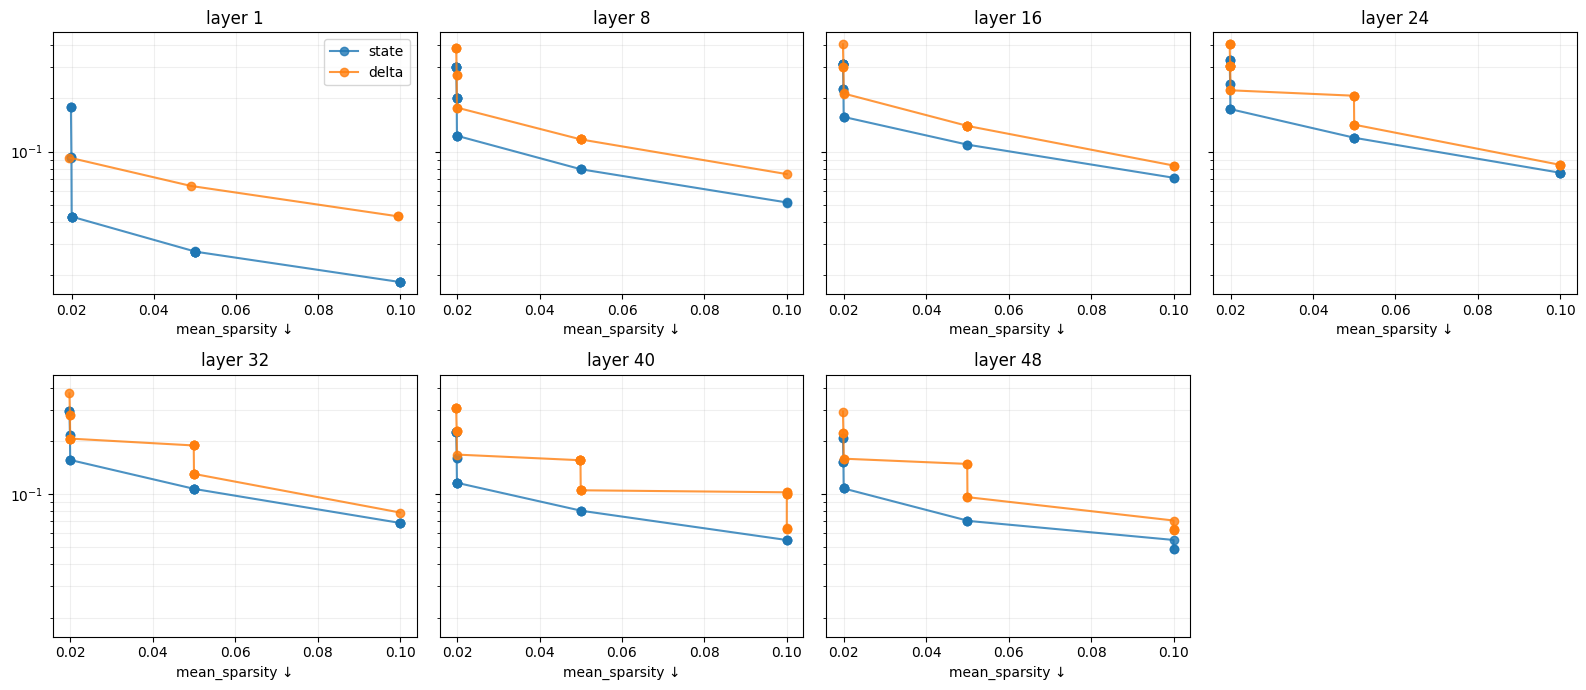

< 0: delta の方が同一 density で NRMSE が良い（更新が圧縮しやすい可能性）


,layer,mean_log_nrmse(delta-state),p50_log_nrmse(delta-state)
2,16,0.228262,0.227236
3,24,0.232611,0.157249
4,32,0.259897,0.183466
1,8,0.375763,0.378552
6,48,0.382870,0.297891
5,40,0.459589,0.465555
0,1,0.803107,0.849063


In [48]:
# 10.5) state vs delta の非対称：同一 density での NRMSE を比較（Pareto 曲線）

def frontier_xy(layer: int, signal: str):
    sub = agg[(agg.layer == layer) & (agg.signal == signal)]
    f = pareto_frontier(sub, x="mean_sparsity", y="nrmse")
    return f["mean_sparsity"].to_numpy(), f["nrmse"].to_numpy(), f


layers_sorted = sorted(agg.layer.unique())
diff_rows = []

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
axes = axes.flatten()
for i, layer in enumerate(layers_sorted):
    ax = axes[i]
    xs_s, ys_s, _ = frontier_xy(layer, "state")
    xs_d, ys_d, _ = frontier_xy(layer, "delta")
    if len(xs_s) < 2 or len(xs_d) < 2:
        ax.set_title(f"layer {layer} (missing)")
        continue

    # overlap range
    x0 = max(xs_s.min(), xs_d.min())
    x1 = min(xs_s.max(), xs_d.max())
    if not np.isfinite(x0) or not np.isfinite(x1) or x1 <= x0:
        continue

    x_common = np.linspace(x0, x1, 50)
    logy_s = np.interp(x_common, xs_s, np.log(ys_s))
    logy_d = np.interp(x_common, xs_d, np.log(ys_d))

    ax.plot(xs_s, ys_s, marker="o", label="state", alpha=0.8)
    ax.plot(xs_d, ys_d, marker="o", label="delta", alpha=0.8)
    ax.set_yscale("log")
    ax.set_title(f"layer {layer}")
    ax.set_xlabel("mean_sparsity ↓")
    ax.grid(True, which="both", alpha=0.2)

    diff_rows.append(
        {
            "layer": layer,
            "mean_log_nrmse(delta-state)": float(np.mean(logy_d - logy_s)),
            "p50_log_nrmse(delta-state)": float(np.median(logy_d - logy_s)),
        }
    )

axes[0].legend()
for j in range(len(layers_sorted), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

diff_df = pd.DataFrame(diff_rows).sort_values("mean_log_nrmse(delta-state)")
print("< 0: delta の方が同一 density で NRMSE が良い（更新が圧縮しやすい可能性）")
display(diff_df)


In [49]:
# 10.6) layer のスイートスポット：NRMSE良・L0小・seed安定
# 3条件: (i) NRMSE が良い, (ii) L0 を上げなくてもそこそこ良い, (iii) seed が安定
# stable-only (CV<=threshold, seeds>=min) の HP に限定して、layer×signal ごとに最良HPを1つ選ぶ

w_l0 = 0.5
w_cv = 0.5

CV_MAX = CV_SEED_THRESH if "CV_SEED_THRESH" in globals() else 0.02
MIN_SEEDS = MIN_SEEDS_KEEP if "MIN_SEEDS_KEEP" in globals() else 2

score_df = agg.copy()

# cv_nrmse が無ければ raw recon から作る（CV は var_norm_sum で割っても不変）
if "cv_nrmse" not in score_df.columns:
    score_df["cv_nrmse"] = score_df["std_val_recon"] / (score_df["mean_val_recon"] + 1e-12)

# stable-only に限定（落ちる layer/signal がある場合は 5.z の表で best_stable を確認）
score_df = score_df[(score_df["n_runs"] >= MIN_SEEDS) & (score_df["cv_nrmse"] <= CV_MAX)].copy()

if score_df.empty:
    raise ValueError("No stable HPs left after filtering; relax CV_MAX or MIN_SEEDS")

if "l0_est" not in score_df.columns:
    score_df["dict_dim"] = (score_df["input_dim"] * score_df["hidden_factor"]).astype(int)
    score_df["l0_est"] = score_df["mean_sparsity"] * score_df["dict_dim"]


def z(x: pd.Series) -> pd.Series:
    return (x - x.mean()) / (x.std(ddof=0) + 1e-12)


score_df["z_nrmse"] = score_df.groupby("signal")["nrmse"].transform(z)
score_df["z_l0"] = score_df.groupby("signal")["l0_est"].transform(z)
score_df["z_cv"] = score_df.groupby("signal")["cv_nrmse"].transform(z)
score_df["score"] = score_df["z_nrmse"] + w_l0 * score_df["z_l0"] + w_cv * score_df["z_cv"]

sweet = (
    score_df.sort_values(["layer", "signal", "score"], kind="stable")
    .groupby(["layer", "signal"], as_index=False)
    .head(1)
    .sort_values(["signal", "score"], kind="stable")
)

display(
    sweet[
        [
            "layer",
            "signal",
            "score",
            "nrmse",
            "explained_var",
            "l0_est",
            "cv_nrmse",
            "hidden_factor",
            "k_frac",
            "l1_lambda",
            "eq_alpha",
        ]
    ]
)

print(f"---recommended layers (stable-only; CV_MAX={CV_MAX}, MIN_SEEDS={MIN_SEEDS}) ---")
display(sweet[["layer", "signal", "score", "nrmse", "l0_est", "cv_nrmse"]])


,layer,signal,score,nrmse,explained_var,l0_est,cv_nrmse,hidden_factor,k_frac,l1_lambda,eq_alpha
1009,48,delta,-1.323796,0.148315,0.851685,409.000000,0.000094,4,0.05,0.0000,0.001
57,1,delta,-1.239963,0.092492,0.907508,318.222524,0.002288,8,0.02,0.0001,0.000
869,40,delta,-1.041914,0.167572,0.832428,327.000000,0.000528,8,0.02,0.0001,0.010
228,8,delta,-1.009118,0.117258,0.882742,818.844930,0.000672,8,0.05,0.0001,0.000
556,24,delta,-0.780501,0.142238,0.857762,819.000000,0.000541,8,0.05,0.0010,0.001
718,32,delta,-0.578576,0.130290,0.869710,819.000000,0.001457,8,0.05,0.0010,0.001
382,16,delta,-0.442389,0.213371,0.786629,326.989360,0.000783,8,0.02,0.0001,0.001
1117,48,state,-1.416361,0.070717,0.929283,819.000000,0.000170,8,0.05,0.0000,0.001
103,1,state,-1.303949,0.098525,0.901475,409.000000,0.000621,2,0.10,0.0001,0.001
961,40,state,-1.146937,0.080630,0.919370,819.000000,0.000487,8,0.05,0.0010,0.001


---recommended layers (stable-only; CV_MAX=0.02, MIN_SEEDS=2) ---


,layer,signal,score,nrmse,l0_est,cv_nrmse
1009,48,delta,-1.323796,0.148315,409.000000,0.000094
57,1,delta,-1.239963,0.092492,318.222524,0.002288
869,40,delta,-1.041914,0.167572,327.000000,0.000528
228,8,delta,-1.009118,0.117258,818.844930,0.000672
556,24,delta,-0.780501,0.142238,819.000000,0.000541
718,32,delta,-0.578576,0.130290,819.000000,0.001457
382,16,delta,-0.442389,0.213371,326.989360,0.000783
1117,48,state,-1.416361,0.070717,819.000000,0.000170
103,1,state,-1.303949,0.098525,409.000000,0.000621
961,40,state,-1.146937,0.080630,819.000000,0.000487


/tmp/ipykernel_479/1945804931.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stats = torch.load(model_dir / f"layer_{layer}" / signal / "stats.pt", map_location="cpu")


,layer,signal,input_dim,var_sum_raw,rms_norm_raw,mean_abs_mean,std_mean
0,1,delta,2048,28.419487,5.331059,0.000459,0.115660
2,8,delta,2048,46.308495,6.805100,0.000525,0.148393
4,16,delta,2048,117.264198,10.828973,0.000859,0.236699
6,24,delta,2048,326.491272,18.069403,0.001877,0.394064
8,32,delta,2048,1162.053345,34.089657,0.003674,0.736971
10,40,delta,2048,9498.818359,97.463036,0.005937,2.039016
12,48,delta,2048,4361.865234,66.048027,0.003767,0.686598
1,1,state,2048,14.434198,3.919460,0.007505,0.082471
3,8,state,2048,24.494612,5.126339,0.009152,0.107956
5,16,state,2048,73.063187,9.091333,0.019620,0.186656


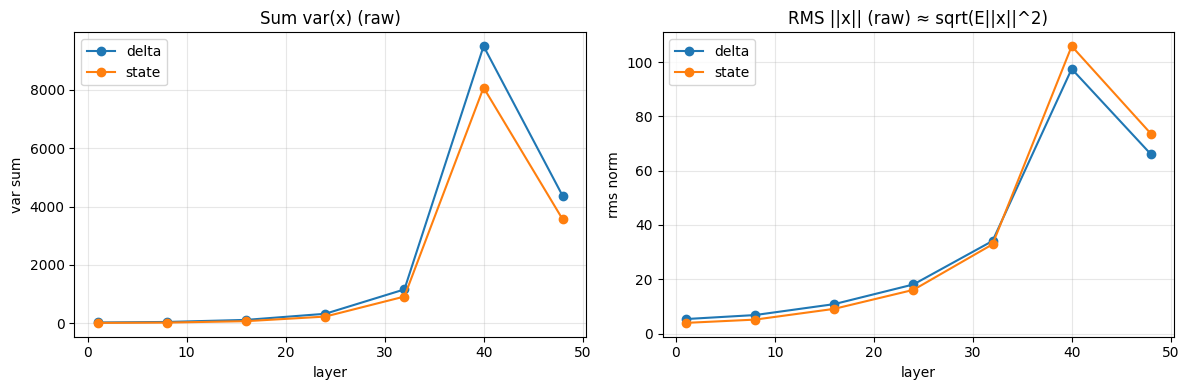

In [50]:
# 10.8) state vs delta の分布チェック（ノルム/分散; optional sampling）
import torch

# stats.pt だけで「スケール」の違いはだいたい見れる（heavy-tail は optional sampling）

def _stats_row(layer: int, signal: str) -> dict:
    stats = torch.load(model_dir / f"layer_{layer}" / signal / "stats.pt", map_location="cpu")
    mean = stats["mean"].float()
    std = stats["std"].float()

    # std = sqrt(var + 1e-6)
    var = torch.clamp(std.pow(2) - 1e-6, min=0.0)
    var_sum = float(var.sum().item())
    rms_norm = float(torch.sqrt((var + mean.pow(2)).sum()).item())

    return {
        "layer": int(layer),
        "signal": signal,
        "input_dim": int(std.numel()),
        "var_sum_raw": var_sum,
        "rms_norm_raw": rms_norm,
        "mean_abs_mean": float(mean.abs().mean().item()),
        "std_mean": float(std.mean().item()),
    }


rows = []
for layer in sorted(agg.layer.unique()):
    for sig in sorted(agg.signal.unique()):
        rows.append(_stats_row(int(layer), sig))

dist_df = pd.DataFrame(rows).sort_values(["signal", "layer"], kind="stable")
display(dist_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for sig, sub in dist_df.groupby("signal"):
    axes[0].plot(sub["layer"], sub["var_sum_raw"], marker="o", label=sig)
axes[0].set_title("Sum var(x) (raw)")
axes[0].set_xlabel("layer")
axes[0].set_ylabel("var sum")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for sig, sub in dist_df.groupby("signal"):
    axes[1].plot(sub["layer"], sub["rms_norm_raw"], marker="o", label=sig)
axes[1].set_title("RMS ||x|| (raw) ≈ sqrt(E||x||^2)")
axes[1].set_xlabel("layer")
axes[1].set_ylabel("rms norm")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- optional: chunk を少し読む（heavy-tail / kurtosis を見たい時だけ） ---
DO_SAMPLE = False
SAMPLE_PER_LAYER = 20000
MAX_CHUNKS = 1
SEED = 0


def _moments(x: np.ndarray) -> dict:
    # x: (n,) 1D
    x = x.astype(np.float64)
    m = float(x.mean())
    v = float(((x - m) ** 2).mean())
    s = float(np.sqrt(v) + 1e-12)
    skew = float(((x - m) ** 3).mean() / (s**3))
    kurt = float(((x - m) ** 4).mean() / (s**4))
    return {"mean": m, "std": s, "skew": skew, "kurtosis": kurt}


def _sample_from_chunks(chunk_dir: Path, n: int, max_chunks: int = 1, seed: int = 0) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed)
    chunk_files = sorted(chunk_dir.glob('chunk_*.pt'))[:max_chunks]
    if not chunk_files:
        raise FileNotFoundError(f"no chunks in {chunk_dir}")

    per = int(np.ceil(n / max(1, len(chunk_files))))
    parts = []
    for p in chunk_files:
        x = torch.load(p, map_location='cpu')
        if not torch.is_tensor(x):
            x = x.get('data', None)
            if x is None:
                raise ValueError(f"unexpected chunk format: {p}")
        m = min(per, x.shape[0])
        idx = torch.randperm(x.shape[0], generator=g)[:m]
        parts.append(x[idx].float())
        del x
    out = torch.cat(parts, dim=0)[:n]
    return out


if DO_SAMPLE:
    sample_rows = []
    for layer in sorted(agg.layer.unique()):
        for sig in sorted(agg.signal.unique()):
            chunk_dir = model_dir / f"layer_{int(layer)}" / sig
            x = _sample_from_chunks(chunk_dir, n=SAMPLE_PER_LAYER, max_chunks=MAX_CHUNKS, seed=SEED)
            norms = torch.linalg.norm(x, dim=1).numpy()
            mom = _moments(norms)
            sample_rows.append({"layer": int(layer), "signal": sig, **mom})
            del x

    sample_df = pd.DataFrame(sample_rows).sort_values(["signal", "layer"], kind="stable")
    display(sample_df)


## 10.7) sample_metrics と下流指標の接続（メモ）

`sample_metrics.pt` は **(i) feature firing の平均**, **(ii) サンプルごとの active 数**, **(iii) サンプルごとの再構成誤差** までで、
**トークン位置ごとの z_t（feature activation）** は保存していません。

ラベル/タグ（例: coreference, POS, dependency, QA 等）と相関/MI を取りたい場合は、

1. 対象 run の `sae_checkpoint.pt` をロード
2. ラベル付きデータをモデルに流して対象 layer の `h_t`（または `delta`）を取り出す
3. checkpoint 内の `mean/std` で正規化して `z_t = SAE.encode(h_norm)` を計算
4. `Corr(z_t^{(i)}, y_t)` / MI / 線形プローブで layer 別に比較

という別途のログ（z_t とラベルの整列）が必要です。必要ならこのノートに「z_t 抽出→集計」セルも追加できます。
